---

# **Practical Data Science**

## **Assignment 1: Data Preparation and Exploration**

**Student:** Do Tung Lam  
**Student ID:** s3963286

---

# Libraries and Resources

In [118]:
# ============================================================================
# TASK 1: DATA PREPARATION WITH IMMUTABLE RAW DATA AND CHANGE TRACKING
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
sns.set_theme(style="whitegrid")

# Define paths
DATA_PATH = "student-data-25s3.csv"
MOVIE_LENS_PATH = "ml-100k"

# Task 1: Student Performance Data Preparation

## Dataset Loading

In [119]:
# ============================================================================
# STEP 1: LOAD RAW DATA (IMMUTABLE - NEVER MODIFIED)
# ============================================================================

# Load raw data - THIS IS NEVER TOUCHED
df_raw = pd.read_csv(DATA_PATH)

# Create stable row identifier IMMEDIATELY
df_raw['row_id'] = range(len(df_raw))

print("\n" + "=" * 80)
print("1.1 RAW DATA LOADED (IMMUTABLE)")
print("=" * 80)
print(f"Dataset shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Stable row identifier 'row_id' created: 0 to {df_raw['row_id'].max()}")

# Create working copy for cleaning
df = df_raw.copy()

print("\n✓ Working copy 'df' created for all cleaning operations")
print("✓ Original 'df_raw' preserved and will never be modified")

# Display first few rows
df_raw.head()


1.1 RAW DATA LOADED (IMMUTABLE)
Dataset shape: 650 rows × 26 columns
Stable row identifier 'row_id' created: 0 to 649

✓ Working copy 'df' created for all cleaning operations
✓ Original 'df_raw' preserved and will never be modified


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
0,GP,F,18,U,GT3,4,4,at_home,teacher,course,2,2,0,no,yes,no,no,4,3,4,3,4,0,11,11,0
1,GP,F,17,U,GT3,1,1,at_home,other,course,1,2,0,no,yes,yes,no,5,3,3,3,2,9,11,11,1
2,GP,F,15,U,LE3,1,1,at_home,other,other,1,2,0,no,yes,yes,no,4,3,2,3,6,12,13,12,2
3,GP,F,15,U,GT3,4,2,health,services,home,1,3,0,yes,yes,yes,yes,3,2,2,5,0,14,14,14,3
4,GP,F,16,U,GT3,3,3,other,other,home,1,2,0,no,yes,no,no,4,3,2,5,0,11,13,13,4


## Initial Data Inspection

After importing the dataset, an initial profiling was conducted using info(), describe(), and value_counts() to assess data types, completeness, and adherence to the attribute definitions provided in the UCI Student Performance documentation. This step establishes whether the dataset conforms to the expected schema and identifies potential data quality issues requiring correction.

In [120]:
# Display data types for all columns
print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

# Display basic statistical summary
print("\n" + "=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
df.describe()


DATA TYPES
school        object
sex           object
age           object
address       object
famsize       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
traveltime     int64
studytime     object
failures       int64
activities    object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
health         int64
absences       int64
G1            object
G2            object
G3             int64
row_id         int64
dtype: object

STATISTICAL SUMMARY


,Medu,Fedu,traveltime,failures,famrel,freetime,goout,health,absences,G3,row_id
count,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.000000,650.00000
mean,2.507692,2.307692,1.573846,0.226154,3.930769,3.178462,3.183077,3.538462,3.729231,11.924615,324.50000
std,1.135274,1.103616,0.751942,0.602710,0.963018,1.051302,1.178397,1.448414,4.775765,3.242939,187.78312
min,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.00000
25%,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,0.000000,10.000000,162.25000
50%,2.000000,2.000000,1.000000,0.000000,4.000000,3.000000,3.000000,4.000000,2.000000,12.000000,324.50000
75%,4.000000,3.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,6.000000,14.000000,486.75000
max,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,649.00000


In [121]:
df_raw.describe(include=["object"])  # Summary for categorical columns

,school,sex,age,address,famsize,Mjob,Fjob,reason,studytime,activities,higher,internet,romantic,G1,G2
count,649,649,650,650,650,649,649,650,647,650,650,650,650,649,650
unique,2,2,14,3,3,9,7,5,10,3,3,3,3,20,17
top,GP,F,17,U,GT3,other,other,course,2,no,yes,yes,no,10,11
freq,423,384,178,449,456,262,360,286,301,330,578,500,407,93,103


**Data Type Assessment**

Although the UCI documentation inconsistently labels *G1* and *G2* as categorical or target attributes, the dataset stores them as numeric grades, and *G3* is clearly the final target. Accordingly, **G1 and G2 are treated as numeric predictors**.

The expected numeric attributes—age, G1, G2, and the ordinal variable studytime—were incorrectly stored as object types. These mismatches typically arise from non-numeric tokens and prevent proper type coercion, obstructing valid statistical summaries and modelling.

**Data Completeness**

All current numeric type variables contain complete data across all 650 rows. Several object-type columns (**school**, **sex**, **Mjob**, **Fjob**, **studytime**, and **G1)**—show signs of potential missing values or mixed data types. These inconsistencies can disrupt categorical encoding and may introduce bias if the missingness mechanism is not random.

**Data Validity**

Comparing each feature against its defined domain revealed additional issues:

- failures contains values outside the valid 0–4 range.
- For object columns, address attribute should contain only 'U' (urban) or 'R' (rural), but 3 categories are observed, reason attribute is documented to include 4 categories, but 5 unique values were detected and more deviations columns will be logged in the next step.

These deviations indicate mislabeled or erroneous entries that compromise interpretability and model readiness. Given these findings, the next step is a systematic inspection of unique values in each categorical attribute to identify all incorrect, inconsistent, or undocumented categories.

### Duplicate Rows Detection

In [122]:
# Check for duplicate rows
print("\n" + "=" * 80)
print("DUPLICATE ROWS")
print("=" * 80)

# Check duplicates excluding row_id (since row_id is always unique)
duplicate_count = df.drop(columns=["row_id"]).duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


DUPLICATE ROWS
Number of duplicate rows: 6


**Row Duplication**: There are 6 duplicate rows found in the dataset. Because the dataset lacks a unique identifier, removing duplicates could risk discarding legitimate cases where different students share similar attributes. Therefore, the duplicates rows are not removed in the dataset.

In [123]:
object_cols = df.select_dtypes(include=["object"]).columns

print("\nCategorical columns and their unique values with counts:")
unique_cols_data = []

for col in object_cols:
    # Get value counts as a dictionary
    value_counts = df[col].value_counts().to_dict()
    unique_cols_data.append({"Feature": col, "Unique Values (Count)": value_counts})

unique_cols = pd.DataFrame(unique_cols_data)

# Display all columns without truncation
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    display(unique_cols)


Categorical columns and their unique values with counts:


,Feature,Unique Values (Count)
0,school,"{'GP': 423, 'MS': 226}"
1,sex,"{'F': 384, 'M': 265}"
2,age,"{'17': 178, '16': 173, '18': 138, '15': 111, '19': 32, '20': 8, '170': 2, '21': 2, '22': 1, '105': 1, '106': 1, '115': 1, '2O': 1, '1O': 1}"
3,address,"{'U': 449, 'R': 200, '0': 1}"
4,famsize,"{'GT3': 456, 'LE3': 193, '0': 1}"
5,Mjob,"{'other': 262, 'services': 130, 'at_home': 127, 'teacher': 73, 'health': 46, 'at home': 4, 'service': 3, 'home': 3, '0': 1}"
6,Fjob,"{'other': 360, 'services': 179, 'at_home': 44, 'teacher': 37, 'health': 23, 'others': 5, '0': 1}"
7,reason,"{'course': 286, 'home': 150, 'reputation': 142, 'other': 71, '0': 1}"
8,studytime,"{'2': 301, '1': 203, '3': 99, '4': 34, '-': 3, '11': 2, '10': 2, '6': 1, '7': 1, '8': 1}"
9,activities,"{'no': 330, 'yes': 319, '0': 1}"


**Missing and Non-Standard Null Representations:** The dataset contains only small percentage (<= 1%) of **both standard and hidden missing values**, often encoded as symbols or strings. ****Missing values appear in multiple non-standard forms, including 'X', 'nan', '0', and '-', rather than a unified null representation. Missing codes prevent correct null detection, interfere with categorical encoding, and may bias any downstream imputation procedures. Therefore, these missing required to be converted to a single NaN representation.

**Incorrect Data Types and Mixed Formatting:** Several variables that should contain integer values (e.g., age, G1, G2, studytime) were inferred as object type due to the presence of non-numeric values such as '1O', '2O', and 'X'. These typographical distortions violate the expected numeric domain and must be corrected to allow coercion into appropriate data types. Similarly, mixed formatting within the Mjob and Fjob attributes (e.g., 'at home', 'at_home', 'home') reflects semantic inconsistencies not supported by the documented categories.

**Out-of-Range Numeric Values:** Numeric variables exhibit several values outside their documented domains. Examples include ages exceeding the plausible range for secondary school students (e.g., 105, 170), studytime values as high as 11 despite the documented 1–4 encoding, and implausible grade values such as 132 (valid range: 0–20). These values represent clear schema violations and require conversion to missing values to prevent distortion of distributions and summary statistics.

**Invalid or Inconsistent Category Encodings:** Numerous categorical variables contain values do not present in their documented level sets. For example, the address variable should only contain 'U' (urban) or 'R' (rural), yet additional categories were observed. The reason attribute, documented to contain four valid categories, appears with five distinct values. Binary variables such as activities, romantic, and internet deviate from the documented 'yes'/'no' encoding through the presence of '0', suggesting data entry errors rather than alternative encoding standards. Since these values with 0 occur only once in each columns, they will be reviewed whether they represent true anomalies or broader formatting errors.

In [124]:
# get all the rows with 0 as binary values in the dataset
print('Row(s) with 0 as address:', display(df[df['address'] == '0']))
print('Row(s) with 0 as famsize:', display(df[df['famsize'] == '0']))
print('Rows with 0 as Mjob:', display(df[df['Mjob'] == '0']))
print('Rows with 0 as Fjob:', display(df[df['Fjob'] == '0']))
print('Rows with 0 as reason:', display(df[df['reason'] == '0']))
print('Rows with 0 as activities:', display(df[df['activities'] == '0']))
print('Rows with 0 as higher:', display(df[df['higher'] == '0']))
print('Rows with 0 as internet:', display(df[df['internet'] == '0']))
print('Rows with 0 as romantic:', display(df[df['romantic'] == '0']))


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649


Row(s) with 0 as address: None


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649


Row(s) with 0 as famsize: None


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649


...

Rows with 0 as higher: None


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649


Rows with 0 as internet: None


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649


Rows with 0 as romantic: None


**Identification of a Fully Corrupted Record:** Row 649 displays multiple simultaneous schema violations: missing values in required fields (e.g., school, sex), extreme age values (170), invalid grade values (e.g., G1 = 142), and inconsistent binary encodings. The density of errors indicates wholesale record corruption rather than isolated typographical mistakes. Retaining this row would significantly distort descriptive statistics and modelling outputs; thus, it will be removed.

### Missing Values Detection

In [125]:
# Check for standard missing values (NaN, None)
print("\n" + "=" * 80)
print("MISSING VALUES (Standard NaN)")
print("=" * 80)
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame(
    {"Missing Count": missing_counts, "Percentage": missing_pct}
)
print(missing_summary[missing_summary["Missing Count"] > 0])

# Check for non-standard missing value representations
print("\n" + "=" * 80)
print("NON-STANDARD MISSING VALUES")
print("=" * 80)

# Check for various missing value representations in all columns
missing_representations = ["-", "nan", "X"]
for col in df.columns:
    for missing_val in missing_representations:
        count = (df[col].astype(str) == missing_val).sum()
        if count > 0:
            print(f"Column '{col}': Found {count} instances of '{missing_val}'")

# total number of missing values in each  in the dataset


MISSING VALUES (Standard NaN)
           Missing Count  Percentage
school                 1        0.15
sex                    1        0.15
Mjob                   1        0.15
Fjob                   1        0.15
studytime              3        0.46
G1                     1        0.15

NON-STANDARD MISSING VALUES
Column 'school': Found 1 instances of 'nan'
Column 'sex': Found 1 instances of 'nan'
Column 'Mjob': Found 1 instances of 'nan'
Column 'Fjob': Found 1 instances of 'nan'
Column 'studytime': Found 3 instances of '-'
Column 'studytime': Found 3 instances of 'nan'
Column 'G1': Found 1 instances of 'nan'
Column 'G1': Found 3 instances of 'X'
Column 'G2': Found 4 instances of '-'


## Data Cleaning

The goal of the cleaning process is to produce a dataset with consistent data types, standardised missing values, valid ranges, and properly encoded categorical variables. Each step below includes the justification for the action and its impact on data quality.

In [126]:
# ============================================================================
# STEP 2: REMOVE CORRUPTED ROWS
# ============================================================================

print("\n" + "=" * 80)
print("3.1 REMOVE CORRUPTED ROWS")
print("=" * 80)

# Save state before change
df_before = df.copy()

# Identify corrupted row
corrupted_row_id = 649
print(f"Corrupted row identified: row_id={corrupted_row_id}")

# Show the corrupted row
print("\nCorrupted row being removed:")
display(df_raw[df_raw['row_id'] == corrupted_row_id])

# Remove from df (df_raw remains untouched)
df = df[df['row_id'] != corrupted_row_id].copy()

print(f"\n✓ Removed row_id={corrupted_row_id} from df")
print(f"✓ df_raw remains unchanged with {len(df_raw)} rows")
print(f"✓ df now has {len(df)} rows")


3.1 REMOVE CORRUPTED ROWS
Corrupted row identified: row_id=649

Corrupted row being removed:


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649



✓ Removed row_id=649 from df
✓ df_raw remains unchanged with 650 rows
✓ df now has 649 rows


**Remove corrupted row:** The first step involved removing corrupted row 649, which showed multiple severe attribute violations. The density of errors indicates full-row corruption, not isolated typos. Retaining it would have distorted descriptive statistics, skewed distributional estimates, and potentially biased any model trained on the data; therefore, the row was removed entirely.

### Handle Non-Standard Missing Values

**Standardize missing values:** All categorical columns have non-standard placeholders ('-', 'X', 'nan' as a literal string), ‘0’ value has been cleaned as they are concentrated in the deleted corrupted row. These are replaced with unified NaN so that missingness is explicitly recognized by pandas and preprocessing tools, avoiding false category inclusion and enable accurate imputation.

In [127]:
# ============================================================================
# STEP 3: REPLACE NON-STANDARD MISSING VALUES
# ============================================================================

print("\n" + "=" * 80)
print("3.2 HANDLE NON-STANDARD MISSING VALUES")
print("=" * 80)

# Get object columns (excluding row_id)
object_cols = df.select_dtypes(include=["object"]).columns

# Replace non-standard missing value representations with NaN
missing_values = ["-", "nan", "X"]

# Track changes
changes_made = []
for col in object_cols:
    # Find rows that will be changed
    mask = df[col].isin(missing_values)
    if mask.any():
        affected_rows = df[mask][['row_id', col]].copy()
        affected_rows['column'] = col
        affected_rows['old_value'] = affected_rows[col]
        affected_rows['new_value'] = np.nan
        changes_made.append(affected_rows[['row_id', 'column', 'old_value', 'new_value']])
    
    df[col] = df[col].replace(missing_values, np.nan)

print(f"✓ Replaced non-standard missing values ('-', 'nan', 'X') with NaN in df")
print(f"✓ df_raw remains untouched")

# Show changes
if changes_made:
    all_changes = pd.concat(changes_made, ignore_index=True)
    print(f"\nTotal values changed: {len(all_changes)}")
    print("\nFirst 20 changes:")
    display(all_changes.head(20))
    
    print("\nChanges by column:")
    print(all_changes.groupby('column').size())
else:
    print("\nNo non-standard missing values found")

print("\nMissing values per column in df:")
print(df.isna().sum()[df.isna().sum() > 0])


3.2 HANDLE NON-STANDARD MISSING VALUES
✓ Replaced non-standard missing values ('-', 'nan', 'X') with NaN in df
✓ df_raw remains untouched

Total values changed: 10

First 20 changes:


,row_id,column,old_value,new_value
0,345,studytime,-,NaN
1,346,studytime,-,NaN
2,383,studytime,-,NaN
3,308,G1,X,NaN
4,309,G1,X,NaN
5,311,G1,X,NaN
6,21,G2,-,NaN
7,22,G2,-,NaN
8,319,G2,-,NaN
9,320,G2,-,NaN



Changes by column:
column
G1           3
G2           4
studytime    3
dtype: int64

Missing values per column in df:
Mjob         1
Fjob         1
studytime    6
G1           4
G2           4
dtype: int64


### Fix Categorical Typos

**Correct typographical encoding errors:** Age includes values such as '1O' and '2O', where the letter **O** replaces the digit 0. These are corrected to '10' and '20' so that the corrected values fall within realistic student age ranges and restores numeric validity and prevents conversion failures.

### Fix Age Column Typos

In [128]:
# ============================================================================
# STEP 5: FIX AGE COLUMN TYPOS
# ============================================================================

print("\n" + "=" * 80)
print("3.4 FIX AGE COLUMN TYPOS")
print("=" * 80)

# Track changes
age_changes = []
age_replacements = {"1O": "10", "2O": "20"}

for old_val, new_val in age_replacements.items():
    mask = df["age"].astype(str) == old_val
    if mask.any():
        affected = df[mask][['row_id', 'age']].copy()
        affected['column'] = 'age'
        affected['old_value'] = old_val
        affected['new_value'] = new_val
        age_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])

# Fix age column typos (only in df)
df["age"] = df["age"].astype(str).replace(age_replacements)

print("✓ Fixed age column typos ('1O' → '10', '2O' → '20') in df")
print(f"✓ df_raw remains untouched")

# Show changes
if age_changes:
    changes_df = pd.concat(age_changes, ignore_index=True)
    print(f"\nTotal age typos fixed: {len(changes_df)}")
    print("\nChanges summary:")
    display(changes_df.groupby(['old_value', 'new_value']).size().reset_index(name='count'))
    print("\nAll affected rows:")
    display(changes_df)
else:
    print("\nNo age typos found")

print("\nAge value counts in df:")
print(df['age'].value_counts().sort_index())


3.4 FIX AGE COLUMN TYPOS
✓ Fixed age column typos ('1O' → '10', '2O' → '20') in df
✓ df_raw remains untouched

Total age typos fixed: 2

Changes summary:


,old_value,new_value,count
0,1O,10,1
1,2O,20,1



All affected rows:


,row_id,column,old_value,new_value
0,556,age,1O,10
1,555,age,2O,20



Age value counts in df:
age
10       1
105      1
106      1
115      1
15     111
16     173
17     178
170      1
18     138
19      32
20       9
21       2
22       1
Name: count, dtype: int64


### Convert Data Types

**Assign correct data types**

After replacing inconsistent type of values, columns are grouped as numeric, ordinal, or nominal and converted accordingly to match the UCI specification:

- **Numeric:** age, G1, G2, G3, absences
- **Ordinal:** Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, health
- **Nominal:** school, reason, sex, address, famsize, Mjob, Fjob, activities, higher, internet, romantic

This ensures correct statistical handling of ordinal relationships, prevents inappropriate numeric interpretation of nominal variables**.**

In [129]:
# ============================================================================
# STEP 6: CONVERT COLUMNS TO APPROPRIATE TYPES
# ============================================================================

print("\n" + "=" * 80)
print("3.5 CONVERT COLUMNS TO APPROPRIATE TYPES")
print("=" * 80)

# Define column categories
numeric_cols = ["age", "G1", "G2", "G3", "absences"]
ordinal_cols = ["Medu", "Fedu", "traveltime", "studytime", "failures", 
                "famrel", "freetime", "goout", "health"]
nominal_cols = ["school", "reason", "sex", "address", "famsize", "Mjob", "Fjob", 
                "activities", "higher", "internet", "romantic"]

# Track type conversion issues (values that become NaN after conversion)
conversion_changes = []

# Convert numeric columns (only in df)
for col in numeric_cols:
    before_na = df[col].isna().sum()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    after_na = df[col].isna().sum()
    
    if after_na > before_na:
        # Find rows where conversion created new NaN values
        newly_na = after_na - before_na
        print(f"  {col}: {newly_na} values couldn't be converted to numeric (set to NaN)")

print("✓ Converted numeric columns in df")

# Convert nominal columns to object (only in df)
whitespace_removed = []
for col in nominal_cols:
    before = df[col].copy()
    df[col] = df[col].astype('object').str.strip()
    
    # Check for whitespace removal
    changed_mask = before.notna() & (before != df[col])
    if changed_mask.any():
        affected = df[changed_mask][['row_id', col]].copy()
        affected['column'] = col
        affected['old_value'] = before[changed_mask].values
        affected['new_value'] = df[col][changed_mask].values
        whitespace_removed.append(affected[['row_id', 'column', 'old_value', 'new_value']])

print("✓ Converted nominal columns to categorical in df")

# Show whitespace removal
if whitespace_removed:
    ws_changes_df = pd.concat(whitespace_removed, ignore_index=True)
    print(f"\n  Whitespace trimmed from {len(ws_changes_df)} values:")
    print("\n  Changes by column:")
    print(ws_changes_df.groupby('column').size())
    print("\n  First 10 whitespace changes:")
    display(ws_changes_df.head(10))

# Convert ordinal columns to int (only in df)
for col in ordinal_cols:
    before_na = df[col].isna().sum()
    df[col] = pd.to_numeric(df[col], errors="coerce")
    after_na = df[col].isna().sum()
    
    if after_na > before_na:
        newly_na = after_na - before_na
        print(f"  {col}: {newly_na} values couldn't be converted (set to NaN)")

print("✓ Converted ordinal columns to ordered categorical in df")
print(f"✓ df_raw remains untouched with original dtypes")


3.5 CONVERT COLUMNS TO APPROPRIATE TYPES
✓ Converted numeric columns in df
✓ Converted nominal columns to categorical in df
✓ Converted ordinal columns to ordered categorical in df
✓ df_raw remains untouched with original dtypes


**Validate and standardise nominal categories:** Whitespace is checked among nominal attributes and it is confirmed to be absent. Then category labels are corrected to match the UCI specification: "service" → "services". "at home" / "home" → "at_home", "others" → "other". This prevents artificial category fragmentation and improves interpretability of the results.

In [130]:
print("Checking for whitespace in nominal columns:")
print("=" * 60)

has_whitespace = False
for col in nominal_cols:
    # Check for leading/trailing whitespace
    whitespace_mask = df[col].notna() & (df[col] != df[col].str.strip())
    whitespace_count = whitespace_mask.sum()

    if whitespace_count > 0:
        print(f"⚠️  '{col}' has {whitespace_count} entries with whitespace")
        has_whitespace = True
    else:
        print(f"✓ '{col}' - no whitespace detected")

if not has_whitespace:
    print("\n✓ All nominal columns are clean (no whitespace)")
else:
    print("\n⚠️  Some columns contain whitespace - will be stripped")

Checking for whitespace in nominal columns:
✓ 'school' - no whitespace detected
✓ 'reason' - no whitespace detected
✓ 'sex' - no whitespace detected
✓ 'address' - no whitespace detected
✓ 'famsize' - no whitespace detected
✓ 'Mjob' - no whitespace detected
✓ 'Fjob' - no whitespace detected
✓ 'activities' - no whitespace detected
✓ 'higher' - no whitespace detected
✓ 'internet' - no whitespace detected
✓ 'romantic' - no whitespace detected

✓ All nominal columns are clean (no whitespace)


In [131]:
# ============================================================================
# STEP 4: FIX CATEGORICAL TYPOS
# ============================================================================

print("\n" + "=" * 80)
print("3.3 FIX CATEGORICAL TYPOS")
print("=" * 80)

# Track changes for Mjob
mjob_changes = []
mjob_replacements = {"service": "services", "at home": "at_home", "home": "at_home", "others": "other"}
for old_val, new_val in mjob_replacements.items():
    mask = df["Mjob"] == old_val
    if mask.any():
        affected = df[mask][['row_id', 'Mjob']].copy()
        affected['column'] = 'Mjob'
        affected['old_value'] = old_val
        affected['new_value'] = new_val
        mjob_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])

# Track changes for Fjob
fjob_changes = []
fjob_replacements = {"service": "services", "at home": "at_home", "home": "at_home", "others": "other"}
for old_val, new_val in fjob_replacements.items():
    mask = df["Fjob"] == old_val
    if mask.any():
        affected = df[mask][['row_id', 'Fjob']].copy()
        affected['column'] = 'Fjob'
        affected['old_value'] = old_val
        affected['new_value'] = new_val
        fjob_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])

# Apply fixes
df["Mjob"] = df["Mjob"].replace(mjob_replacements)
df["Fjob"] = df["Fjob"].replace(fjob_replacements)

print("✓ Fixed categorical typos in Mjob and Fjob columns in df")
print(f"✓ df_raw remains untouched")

# Show changes
all_job_changes = []
if mjob_changes:
    all_job_changes.extend(mjob_changes)
if fjob_changes:
    all_job_changes.extend(fjob_changes)

if all_job_changes:
    changes_df = pd.concat(all_job_changes, ignore_index=True)
    print(f"\nTotal categorical typos fixed: {len(changes_df)}")
    print("\nChanges summary:")
    display(changes_df.groupby(['column', 'old_value', 'new_value']).size().reset_index(name='count'))
    print("\nFirst 15 affected rows:")
    display(changes_df.head(15))

print(f"\nMjob unique values: {sorted([x for x in df['Mjob'].unique() if pd.notna(x)])}")
print(f"Fjob unique values: {sorted([x for x in df['Fjob'].unique() if pd.notna(x)])}")


3.3 FIX CATEGORICAL TYPOS
✓ Fixed categorical typos in Mjob and Fjob columns in df
✓ df_raw remains untouched

Total categorical typos fixed: 15

Changes summary:


,column,old_value,new_value,count
0,Fjob,others,other,5
1,Mjob,at home,at_home,4
2,Mjob,home,at_home,3
3,Mjob,service,services,3



First 15 affected rows:


,row_id,column,old_value,new_value
0,150,Mjob,service,services
1,151,Mjob,service,services
2,152,Mjob,service,services
3,219,Mjob,at home,at_home
4,222,Mjob,at home,at_home
5,232,Mjob,at home,at_home
6,233,Mjob,at home,at_home
7,234,Mjob,home,at_home
8,235,Mjob,home,at_home
9,242,Mjob,home,at_home



Mjob unique values: ['at_home', 'health', 'other', 'services', 'teacher']
Fjob unique values: ['at_home', 'health', 'other', 'services', 'teacher']


**Apply domain-based validity rules:** Domain-based validity rules were then enforced across the dataset. Values falling outside documented permissible ranges were replaced with NaN, as they represent structural errors rather than legitimate observations: failures (0-2), studytime (1-4), age (15-22), [G1, G2, G3] (0-20). Applying these domain constraints ensures that implausible or impossible values do not contaminate summary statistics or influence predictive modelling.

In [132]:
# ============================================================================
# STEP 7: REPLACE INVALID VALUES WITH NaN
# ============================================================================

print("\n" + "=" * 80)
print("3.6 REPLACE INVALID VALUES WITH NaN")
print("=" * 80)

all_invalid_changes = []

# Invalid failures
invalid_failure_mask = ~df['failures'].isin([0, 1, 2])
if invalid_failure_mask.sum() > 0:
    affected = df[invalid_failure_mask][['row_id', 'failures']].copy()
    affected['column'] = 'failures'
    affected['old_value'] = affected['failures']
    affected['new_value'] = np.nan
    all_invalid_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])
    print(f"Found {invalid_failure_mask.sum()} invalid failure values (not in [0, 1, 2])")
    df.loc[invalid_failure_mask, "failures"] = np.nan

# Invalid studytime
invalid_studytime_mask = ~df["studytime"].isin([1, 2, 3, 4])
if invalid_studytime_mask.sum() > 0:
    affected = df[invalid_studytime_mask][['row_id', 'studytime']].copy()
    affected['column'] = 'studytime'
    affected['old_value'] = affected['studytime']
    affected['new_value'] = np.nan
    all_invalid_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])
    print(f"Found {invalid_studytime_mask.sum()} invalid studytime values (not in [1, 2, 3, 4])")
    df.loc[invalid_studytime_mask, "studytime"] = np.nan

# Invalid ages
invalid_age_mask = (df["age"] < 15) | (df["age"] > 22)
if invalid_age_mask.sum() > 0:
    affected = df[invalid_age_mask][['row_id', 'age']].copy()
    affected['column'] = 'age'
    affected['old_value'] = affected['age']
    affected['new_value'] = np.nan
    all_invalid_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])
    print(f"Found {invalid_age_mask.sum()} invalid ages (< 15 or > 22)")
    df.loc[invalid_age_mask, "age"] = np.nan

# Invalid grades
grade_cols = ["G1", "G2", "G3"]
for col in grade_cols:
    invalid_grade_mask = (df[col] < 0) | (df[col] > 20)
    invalid_count = invalid_grade_mask.sum()
    if invalid_count > 0:
        affected = df[invalid_grade_mask][['row_id', col]].copy()
        affected['column'] = col
        affected['old_value'] = affected[col]
        affected['new_value'] = np.nan
        all_invalid_changes.append(affected[['row_id', 'column', 'old_value', 'new_value']])
        print(f"{col}: Found {invalid_count} invalid grades (< 0 or > 20)")
        df.loc[invalid_grade_mask, col] = np.nan

print("\n✓ Replaced all invalid values with NaN in df")
print(f"✓ df_raw remains untouched with original values")

# Show all invalid value changes
if all_invalid_changes:
    invalid_df = pd.concat(all_invalid_changes, ignore_index=True)
    print(f"\nTotal invalid values replaced: {len(invalid_df)}")
    print("\nInvalid values by column:")
    display(invalid_df.groupby('column').size().reset_index(name='count'))
    print("\nAll invalid values (showing first 30):")
    display(invalid_df.head(30))
else:
    print("\nNo invalid values found")


3.6 REPLACE INVALID VALUES WITH NaN
Found 14 invalid failure values (not in [0, 1, 2])
Found 12 invalid studytime values (not in [1, 2, 3, 4])
Found 5 invalid ages (< 15 or > 22)
G1: Found 2 invalid grades (< 0 or > 20)

✓ Replaced all invalid values with NaN in df
✓ df_raw remains untouched with original values

Total invalid values replaced: 33

Invalid values by column:


,column,count
0,G1,2
1,age,5
2,failures,14
3,studytime,12



All invalid values (showing first 30):


,row_id,column,old_value,new_value
0,18,failures,3.0,NaN
1,78,failures,3.0,NaN
2,131,failures,3.0,NaN
3,169,failures,3.0,NaN
4,170,failures,3.0,NaN
5,179,failures,3.0,NaN
6,237,failures,3.0,NaN
7,279,failures,3.0,NaN
8,478,failures,3.0,NaN
9,543,failures,3.0,NaN


**Convert Categorical Variables:** To ensure efficient storage and enforce correct treatment of categories, all nominal variables were explicitly converted to unordered categorical types, and ordinal variables to ordered categorical types using pandas Categorical() function. This step guarantees that statistical procedures, encoders, and visualizations recognize the intended structure of each categorical field.

In [133]:
for col in nominal_cols:
    df[col] = pd.Categorical(df[col])
print("✓ Converted nominal columns to categorical in df")
for col in ordinal_cols:
    df[col] = pd.Categorical(df[col], ordered=True)

✓ Converted nominal columns to categorical in df


**Review and retain statistical outliers:** Finally, the dataset was examined for potential statistical outliers that, while extreme, remain plausible within the domain. High absenteeism values (20–35), grade extremes at both ends of the performance spectrum (0–5 and 18–20), and the upper-bound age of 22 were retained. These values represent genuine variation in student behavior and performance rather than errors and preserving them maintains the natural distributional richness of the dataset and avoids biasing models toward average cases.

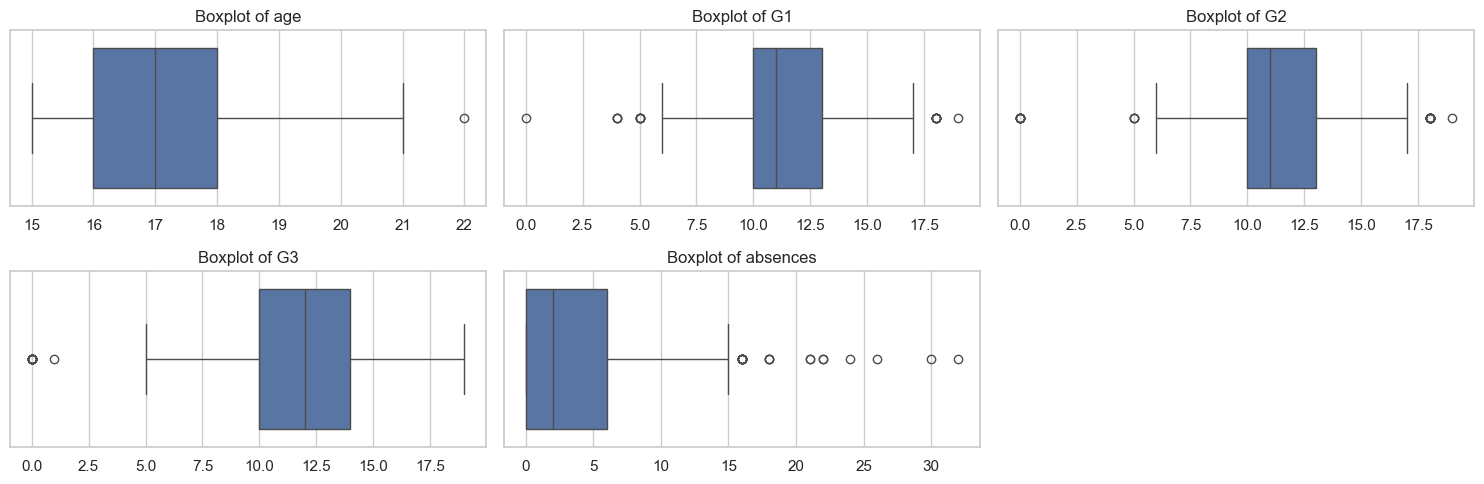

In [134]:
# print all box plots of numeric columns
_, subs = plt.subplots(2, 3, figsize=(15, 5))

for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3
    sns.boxplot(x=df[col], ax=subs[row, col_idx])
    subs[row, col_idx].set_title(f"Boxplot of {col}")
    subs[row, col_idx].set_xlabel("")

# Hide the last empty subplot
subs[1, 2].axis("off")  # Turn off the 6th subplot (index [1,2])

plt.tight_layout()
plt.show()

## Post-Cleaning Validation

In [135]:
# Display cleaned data summary
print("\n" + "=" * 80)
print("CLEANED DATA SUMMARY (df)")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("STATISTICAL SUMMARY (df)")
print("=" * 80)
df.describe()


CLEANED DATA SUMMARY (df)
<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 0 to 648
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   school      649 non-null    category
 1   sex         649 non-null    category
 2   age         644 non-null    float64 
 3   address     649 non-null    category
 4   famsize     649 non-null    category
 5   Medu        649 non-null    category
 6   Fedu        649 non-null    category
 7   Mjob        648 non-null    category
 8   Fjob        648 non-null    category
 9   reason      649 non-null    category
 10  traveltime  649 non-null    category
 11  studytime   637 non-null    category
 12  failures    635 non-null    category
 13  activities  649 non-null    category
 14  higher      649 non-null    category
 15  internet    649 non-null    category
 16  romantic    649 non-null    category
 17  famrel      649 non-null    category
 18  freetime    649 non-null    

,age,absences,G1,G2,G3,row_id
count,644.000000,649.000000,643.000000,645.000000,649.000000,649.000000
mean,16.762422,3.685670,11.381026,11.575194,11.913713,324.000000
std,1.237473,4.648423,2.765398,2.918032,3.233498,187.494444
min,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,0.000000,10.000000,10.000000,10.000000,162.000000
50%,17.000000,2.000000,11.000000,11.000000,12.000000,324.000000
75%,18.000000,6.000000,13.000000,13.000000,14.000000,486.000000
max,22.000000,32.000000,19.000000,19.000000,19.000000,648.000000


In [136]:
# ============================================================================
# TASK 1 COMPLETE: COMPUTE DIFF BETWEEN df_raw AND df
# ============================================================================

print("\n" + "=" * 80)
print("TASK 1 CHANGE ANALYSIS: df_raw vs df")
print("=" * 80)

# ============================================================================
# 1. IDENTIFY DROPPED ROWS
# ============================================================================
print("\n" + "─" * 80)
print("1. DROPPED ROWS")
print("─" * 80)

dropped_row_ids = set(df_raw['row_id']) - set(df['row_id'])
dropped_rows = df_raw[df_raw['row_id'].isin(dropped_row_ids)]

print(f"\n📊 Total rows dropped: {len(dropped_rows)}")
if len(dropped_rows) > 0:
    print(f"Dropped row_ids: {sorted(dropped_row_ids)}")
    print("\nDropped rows details:")
    display(dropped_rows)
else:
    print("✓ No rows were dropped")

# ============================================================================
# 2. IDENTIFY MODIFIED ROWS
# ============================================================================
print("\n" + "─" * 80)
print("2. MODIFIED ROWS (VALUE CHANGES)")
print("─" * 80)

# Get common row_ids
common_row_ids = set(df_raw['row_id']).intersection(set(df['row_id']))

# Align dataframes by row_id for comparison (exclude row_id column itself)
df_raw_aligned = df_raw[df_raw['row_id'].isin(common_row_ids)].set_index('row_id').sort_index()
df_aligned = df[df['row_id'].isin(common_row_ids)].set_index('row_id').sort_index()

# Find rows with any changes
modified_rows = []
change_details = []

for row_id in common_row_ids:
    row_raw = df_raw_aligned.loc[row_id]
    row_clean = df_aligned.loc[row_id]

    changes_in_row = {}
    for col in df_raw_aligned.columns:
        val_raw = row_raw[col]
        val_clean = row_clean[col]

        # Handle NaN comparisons first
        if pd.isna(val_raw) and pd.isna(val_clean):
            continue
        elif pd.isna(val_raw) or pd.isna(val_clean):
            # One is NaN, the other isn't - this IS a change
            changes_in_row[col] = {"old": val_raw, "new": val_clean}
            continue

        # For non-NaN values, try numeric comparison first
        try:
            # Convert both to float for comparison
            if float(val_raw) == float(val_clean):
                continue  # Values are numerically equal, no change
        except (ValueError, TypeError):
            # Not numeric, fall back to string comparison
            if str(val_raw) == str(val_clean):
                continue  # String values match, no change

        # If we get here, values are truly different
        changes_in_row[col] = {"old": val_raw, "new": val_clean}

    if changes_in_row:
        modified_rows.append(row_id)
        change_details.append({
            'row_id': row_id,
            'num_columns_changed': len(changes_in_row),
            'columns_changed': list(changes_in_row.keys()),
            'changes': changes_in_row
        })

print(f"\n📊 Total rows modified: {len(modified_rows)}")
print(f"Percentage of rows modified: {len(modified_rows)/len(common_row_ids)*100:.2f}%")
print('change detail: ', change_details)
# ============================================================================
# 3. DETAILED CHANGE SUMMARY
# ============================================================================
print("\n" + "─" * 80)
print("3. DETAILED CHANGE SUMMARY BY COLUMN")
print("─" * 80)

column_changes = {}
for detail in change_details:
    for col in detail['columns_changed']:
        if col not in column_changes:
            column_changes[col] = 0
        column_changes[col] += 1

if column_changes:
    print("\nNumber of rows affected per column:")
    for col, count in sorted(column_changes.items(), key=lambda x: x[1], reverse=True):
        print(f"  {col:20} : {count:4} rows changed")
else:
    print("\n✓ No column values were modified")

# ============================================================================
# 4. SAMPLE CHANGES (First 10 modified rows)
# ============================================================================
print("\n" + "─" * 80)
print("4. SAMPLE CHANGES (First 10 modified rows)")
print("─" * 80)

for i, detail in enumerate(change_details[:10], 1):
    print(f"\n{'─' * 40}")
    print(f"Row ID: {detail['row_id']}")
    print(f"Columns changed: {detail['num_columns_changed']}")
    print("Changes:")
    for col, change in detail['changes'].items():
        print(f"  {col:15} : '{change['old']}' → '{change['new']}'")

if len(change_details) > 10:
    print(f"\n... and {len(change_details) - 10} more modified rows")

# ============================================================================
# 5. OVERALL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("OVERALL SUMMARY")
print("=" * 80)

print(f"\n📊 df_raw (immutable original):")
print(f"   Rows: {len(df_raw)}")
print(f"   Columns: {len(df_raw.columns)}")
print(f"   Status: ✓ Never modified, preserved for reference")

print(f"\n📊 df (cleaned data):")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Rows dropped: {len(dropped_rows)}")
print(f"   Rows modified: {len(modified_rows)}")
print(f"   Rows unchanged: {len(common_row_ids) - len(modified_rows)}")

print(f"\n📊 Total changes:")
print(f"   Rows affected (dropped or modified): {len(dropped_rows) + len(modified_rows)}")
print(f"   Percentage of data affected: {(len(dropped_rows) + len(modified_rows))/len(df_raw)*100:.2f}%")

# ============================================================================
# 6. EXPORT CHANGE LOG
# ============================================================================
print("\n" + "─" * 80)
print("EXPORTING CHANGE LOGS")
print("─" * 80)

# Export dropped rows
if len(dropped_rows) > 0:
    dropped_rows.to_csv('task1_dropped_rows.csv', index=False)
    print("✓ Dropped rows saved to 'task1_dropped_rows.csv'")

# Export modified rows details
if change_details:
    # 1. Export value changes (individual cell changes)
    change_log = []
    for detail in change_details:
        for col, change in detail["changes"].items():
            change_log.append(
                {
                    "row_id": detail["row_id"],
                    "column": col,
                    "old_value": change["old"],
                    "new_value": change["new"],
                }
            )

    change_log_df = pd.DataFrame(change_log)
    change_log_df.to_csv("task1_value_changes.csv", index=False)
    print("✓ Value changes saved to 'task1_value_changes.csv'")

    # 2. Export complete modified rows with their row_id as index
    modified_row_ids = [detail["row_id"] for detail in change_details]

    # Get complete rows from df_raw (before changes)
    modified_rows_before = (
        df_raw[df_raw["row_id"].isin(modified_row_ids)].set_index("row_id").sort_index()
    )
    modified_rows_before.to_csv("task1_modified_rows_BEFORE.csv")
    print(
        f"✓ Modified rows (BEFORE cleaning) saved to 'task1_modified_rows_BEFORE.csv' ({len(modified_rows_before)} rows)"
    )

    # Get complete rows from df (after changes)
    modified_rows_after = (
        df[df["row_id"].isin(modified_row_ids)].set_index("row_id").sort_index()
    )
    modified_rows_after.to_csv("task1_modified_rows_AFTER.csv")
    print(
        f"✓ Modified rows (AFTER cleaning) saved to 'task1_modified_rows_AFTER.csv' ({len(modified_rows_after)} rows)"
    )

# Drop the row_id column from df to finalize cleaned data
df = df.drop(columns=['row_id'])


TASK 1 CHANGE ANALYSIS: df_raw vs df

────────────────────────────────────────────────────────────────────────────────
1. DROPPED ROWS
────────────────────────────────────────────────────────────────────────────────

📊 Total rows dropped: 1
Dropped row_ids: [649]

Dropped rows details:


,school,sex,age,address,famsize,Medu,Fedu,Mjob,Fjob,reason,traveltime,studytime,failures,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3,row_id
649,NaN,NaN,170,0,0,4,4,0,0,0,4,11,3,0,0,0,0,5,5,5,5,32,132,19,19,649



────────────────────────────────────────────────────────────────────────────────
2. MODIFIED ROWS (VALUE CHANGES)
────────────────────────────────────────────────────────────────────────────────

📊 Total rows modified: 52
Percentage of rows modified: 8.01%
change detail:  [{'row_id': 18, 'num_columns_changed': 1, 'columns_changed': ['failures'], 'changes': {'failures': {'old': np.int64(3), 'new': nan}}}, {'row_id': 21, 'num_columns_changed': 1, 'columns_changed': ['G2'], 'changes': {'G2': {'old': '-', 'new': np.float64(nan)}}}, {'row_id': 22, 'num_columns_changed': 1, 'columns_changed': ['G2'], 'changes': {'G2': {'old': '-', 'new': np.float64(nan)}}}, {'row_id': 73, 'num_columns_changed': 1, 'columns_changed': ['studytime'], 'changes': {'studytime': {'old': '11', 'new': nan}}}, {'row_id': 78, 'num_columns_changed': 2, 'columns_changed': ['studytime', 'failures'], 'changes': {'studytime': {'old': '10', 'new': nan}, 'failures': {'old': np.int64(3), 'new': nan}}}, {'row_id': 102, 'num_co

# Task 2: Exploratory Data Analysis

## Task 2.1: Distribution Analysis

Three variables were selected for visualization: **G2** (numeric), **Mjob** (nominal), and **studytime** (ordinal), based on their relevance to final grade student performance and the diversity of their data types as these metric help make visual analysis more informative and comprehensive.

**Numeric Variable**

A histogram is appropriate for continuous or discrete numeric variables because it shows the underlying distribution, central tendency, and potential skewness or outliers. This helps reveal performance patterns across students.

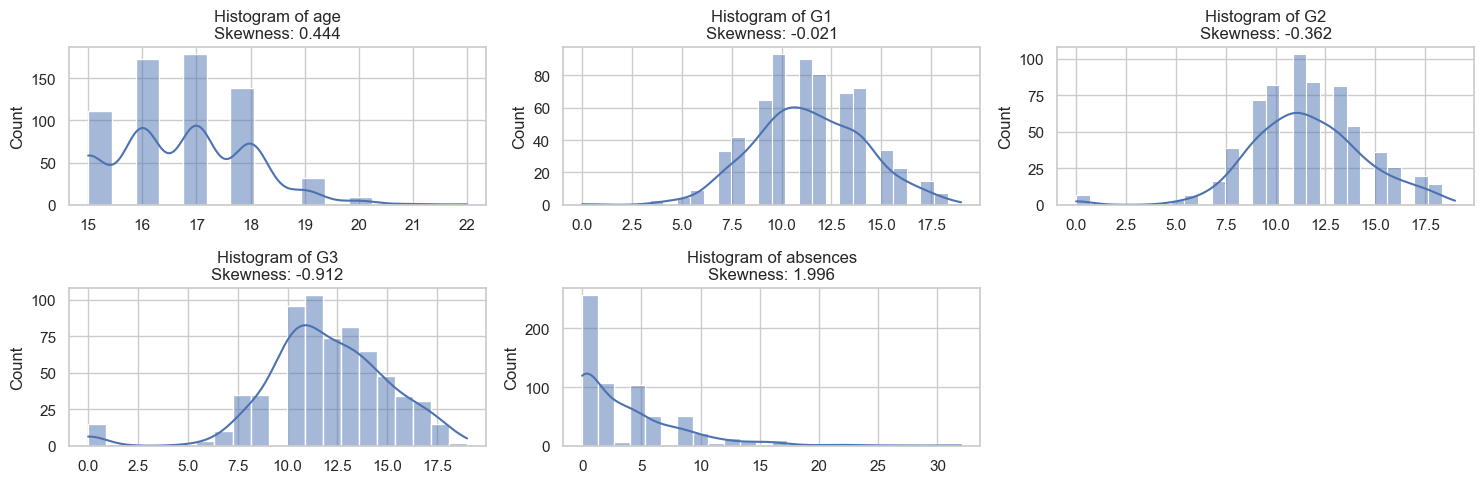

In [137]:
# display all histograms of numeric columns
_, subs = plt.subplots(2, 3, figsize=(15, 5))
for i, col in enumerate(numeric_cols):
    row = i // 3
    col_idx = i % 3

    # Plot histogram with KDE
    sns.histplot(df[col].dropna(), kde=True, ax=subs[row, col_idx])

    # Calculate skewness
    skewness = df[col].dropna().skew()

    # Set title with skewness
    subs[row, col_idx].set_title(f"Histogram of {col}\nSkewness: {skewness:.3f}")
    subs[row, col_idx].set_xlabel("")

# Hide the last empty subplot
subs[1, 2].axis("off")  # Turn off the 6th subplot (index [1,2])

plt.tight_layout()
plt.show()

Among the numerical attributes (age, G1, G2, G3, absences), **G2** was chosen because it is the only variable with missing values and provides strong analytical value for comparing imputation methods in Task 3. **Absences** has no missing data, **G3** is the target and cannot be used, and **G1** is less informative than G2. G2 also has a clean, moderately skewed distribution (–0.362), making it suitable for assessing how imputation affects variable shape. These factors make G2 the most appropriate numerical variable for this task.


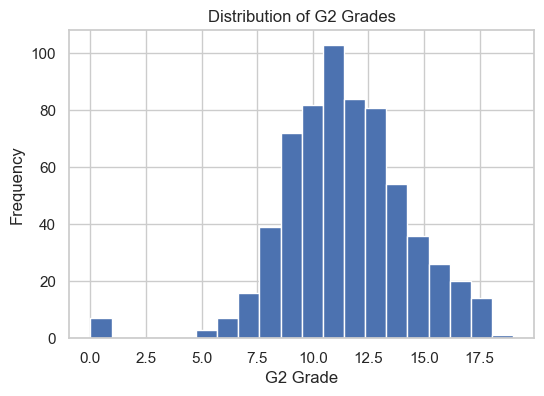

In [138]:
# plot the histogram of G2 column
df["G2"].plot(kind="hist", bins=20, figsize=(6, 4))
plt.title("Distribution of G2 Grades")
plt.xlabel("G2 Grade")
plt.ylabel("Frequency")
plt.show()


The distribution of **G2 grades** is approximately bell-shaped, centred around scores of **10–13**, indicating that most students achieve mid-range performance. The slight left-skew is caused by a small number of very low grades (including zeros), while high grades (16–19) appear less frequently but remain within plausible limits. Overall, the distribution reflects typical academic performance patterns, with most students clustering around average grades and fewer achieving very low or very high marks.

**Nominal Variable:**

A countplot effectively displays the frequency of categories in a nominal variable. Since parental occupation is a non-ordered categorical feature, bar counts are the clearest way to compare category prevalence.

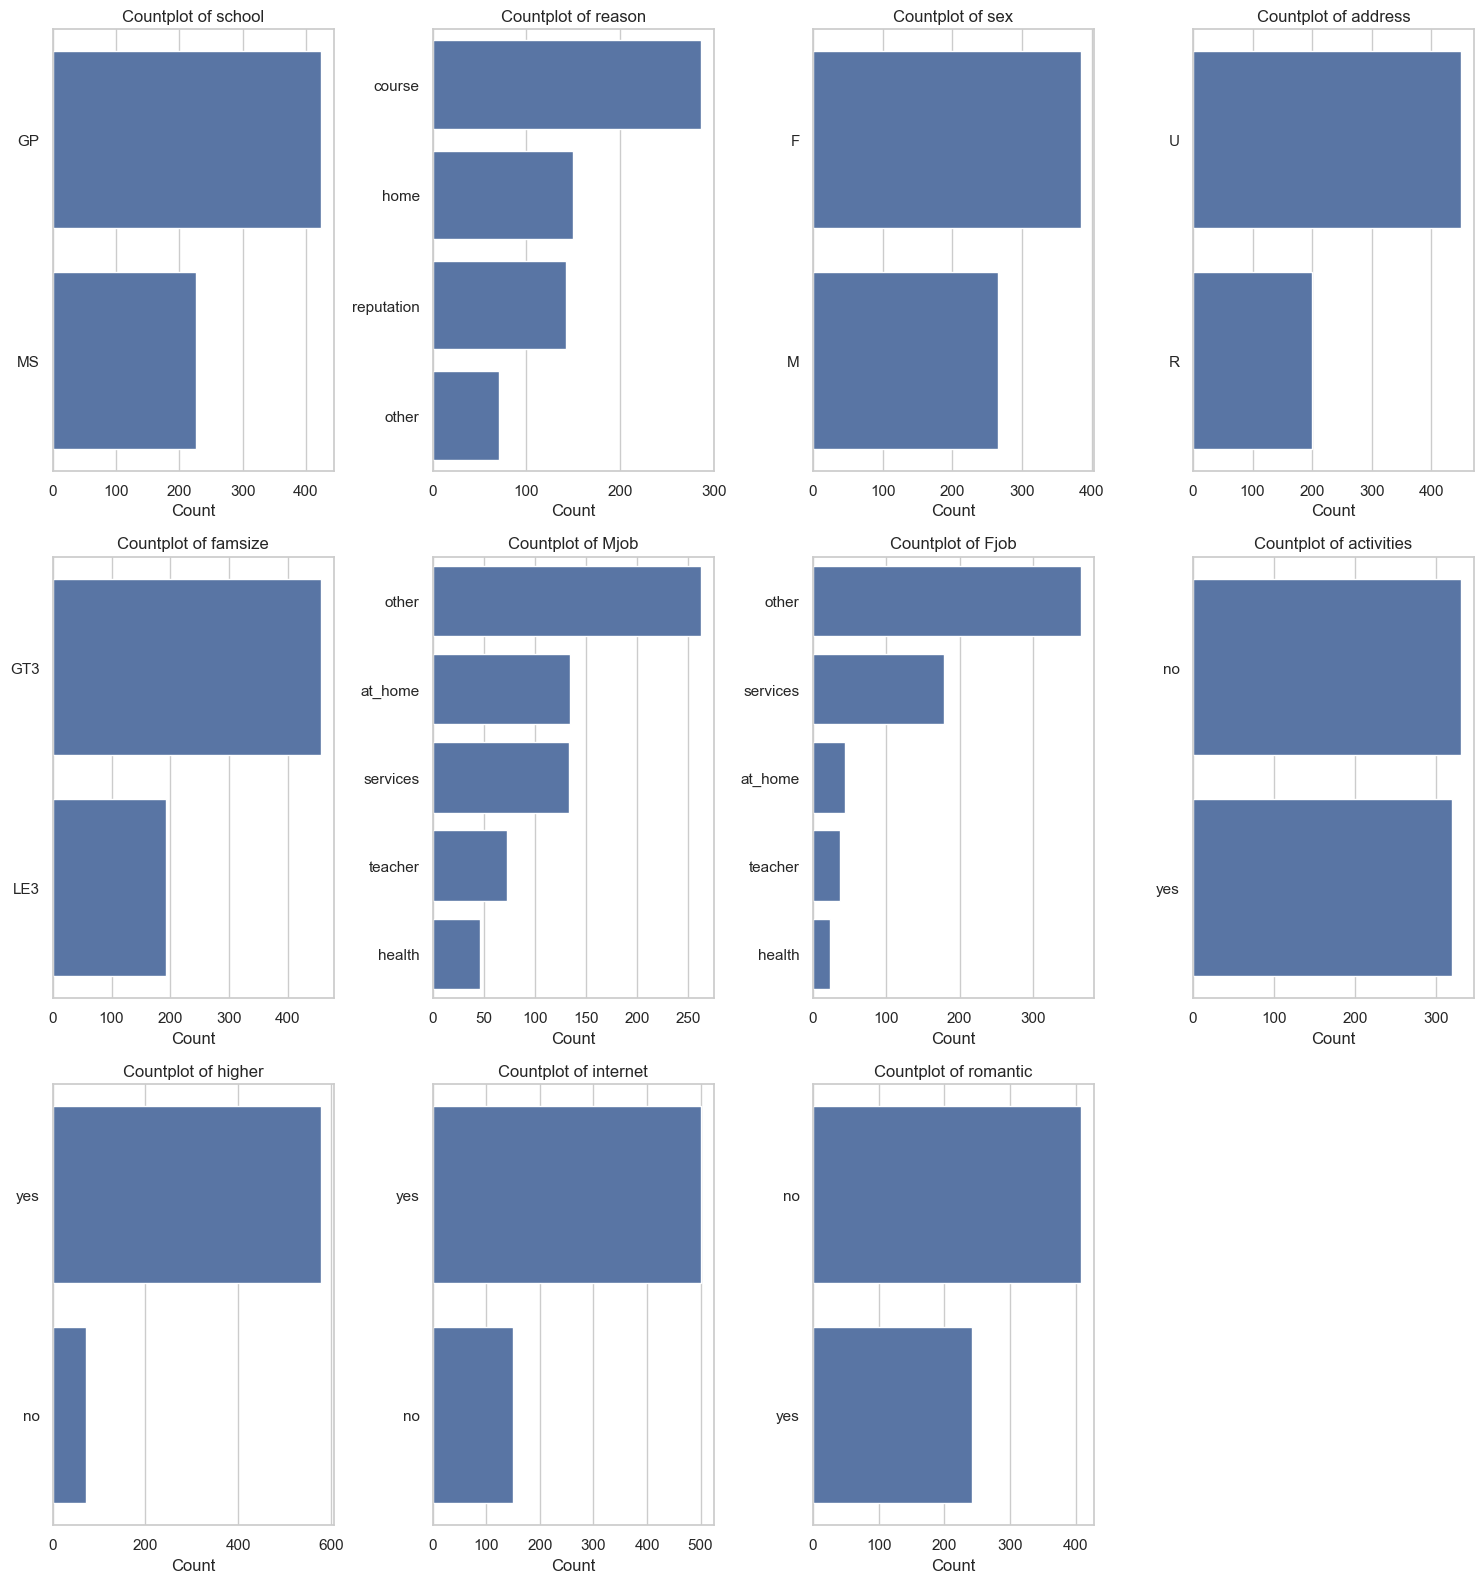

In [139]:
# Display all count plots of nominal columns
_, subs = plt.subplots(3, 4, figsize=(15, 16))
for i, col in enumerate(nominal_cols):
    row = i // 4
    col_idx = i % 4

    # Plot countplot
    sns.countplot(y=df[col], order=df[col].value_counts().index, ax=subs[row, col_idx])

    # Set title
    subs[row, col_idx].set_title(f"Countplot of {col}")
    subs[row, col_idx].set_xlabel("Count")
    subs[row, col_idx].set_ylabel("")

# Hide last empty subplot
subs[2, 3].axis("off")  # Turn off the 12th subplot (index [2,3])
plt.tight_layout()
plt.show()

**Mjob** was chosen as the nominal variable because, unlike simpler two-category attributes (e.g., sex, address, activities), it has five meaningful. It is also more relevant to student performance than alternatives such as school, famsize, or lifestyle variables, as parental occupation is a well-established socio-economic factor influencing academic outcomes. This makes Mjob both more informative and more meaningful for visualization than other nominal features. 

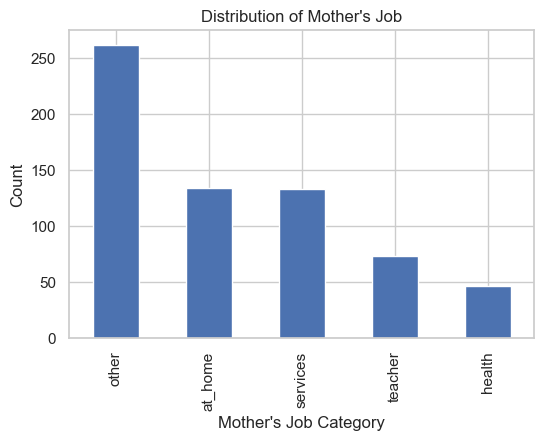

In [140]:
df["Mjob"].value_counts().plot(kind="bar", figsize=(6, 4))
plt.title("Distribution of Mother's Job")
plt.xlabel("Mother's Job Category")
plt.ylabel("Count")
plt.show()

The distribution of **mother’s occupation (Mjob)** is highly uneven, with the *“other”* category dominating the dataset. Occupations such as *services* and *at_home* appear at moderate frequencies, while *teacher* and especially *health* roles are much less common. This imbalance suggests substantial occupational diversity but also indicates that certain professions are under-represented, which may influence any analysis that compares academic outcomes across parental job groups.

**Ordinal variable**

Although ordinal variables have an inherent order, they consist of discrete categories. A countplot highlights how students are distributed across study-time levels while preserving the natural ordering of the scale.

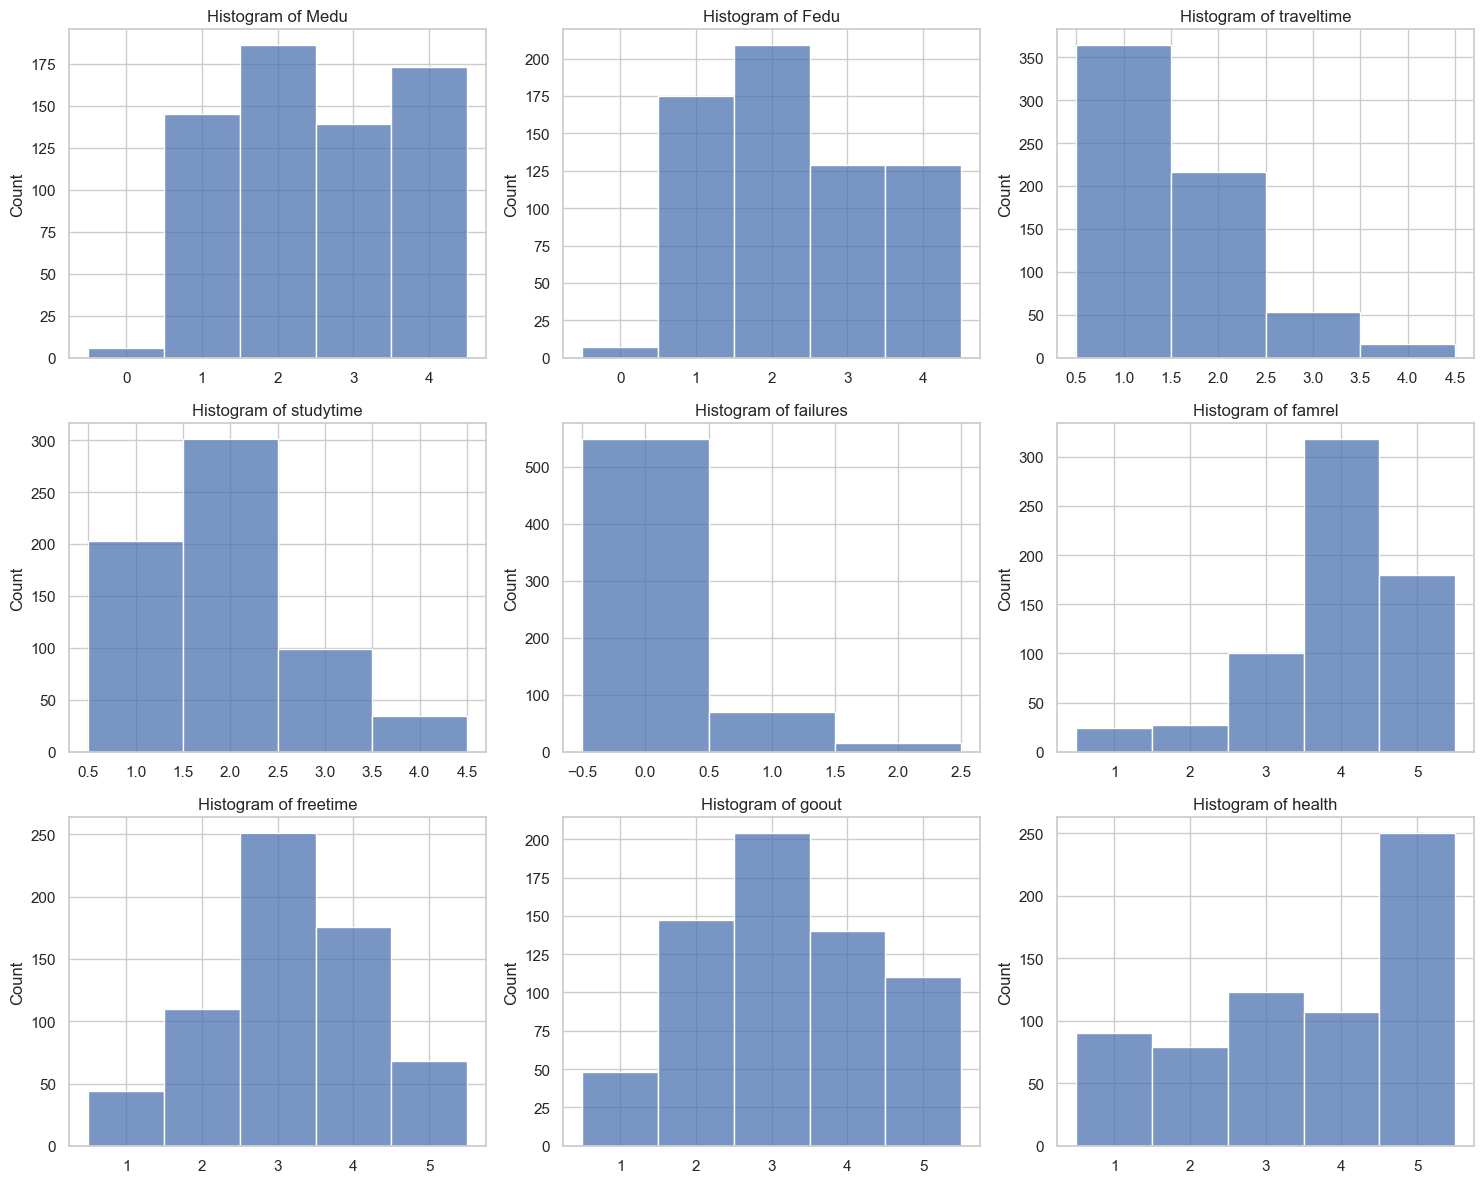

In [141]:
# display all histograms of ordinal columns
_, subs = plt.subplots(3, 3, figsize=(15, 12))
for i, col in enumerate(ordinal_cols):
    row = i // 3
    col_idx = i % 3

    # Plot histogram with KDE
    sns.histplot(df[col].dropna(), kde=False, ax=subs[row, col_idx], discrete=True)

    # Set title with skewness
    subs[row, col_idx].set_title(f"Histogram of {col}")
    subs[row, col_idx].set_xlabel("")

plt.tight_layout()
plt.show()

For the ordinal variable, **studytime** was chosen because it directly reflects students’ study behaviour, making it more meaningful for performance-related analysis than background or rating-based attributes. It also shows a balanced spread across its 1–4 scale, whereas many other ordinal variables are heavily skewed or concentrated in a single category. 

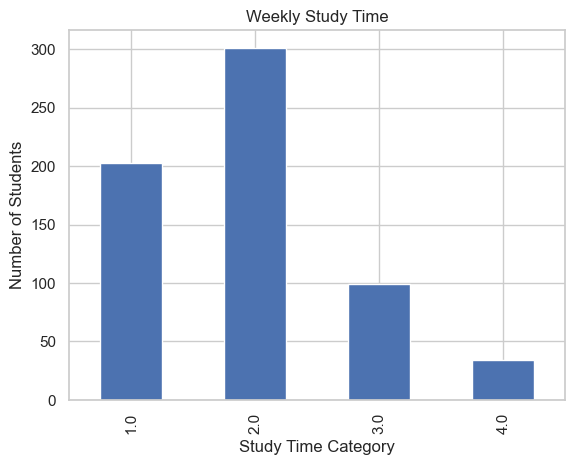

In [142]:
df["studytime"].value_counts().sort_index().plot(kind="bar")
plt.title("Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")
plt.show()

The distribution of *studytime* is strongly right-skewed, with most students reporting study levels of **1 or 2**, indicating relatively low weekly study commitment. Levels **3 and 4** are much less common, suggesting that only a small subset of students engage in higher-intensity study routines. This pattern reflects a typical school population where moderate study habits dominate, and extreme study behaviours are rare.

## Task 2.2: Relationship Analysis

**Study Behavior Influences Academic Performance**

**Hypothesis:** Students who spend more time studying tend to achieve higher final grades. Studytime reflects direct academic effort, while G3 is the final performance outcome. Their relationship is central to understanding learning behaviours. Box plot is chosen for visualization since it compares the distribution of a continuous response (G3) across ordered studytime categories while revealing differences in median, IQR, and distributional spread.

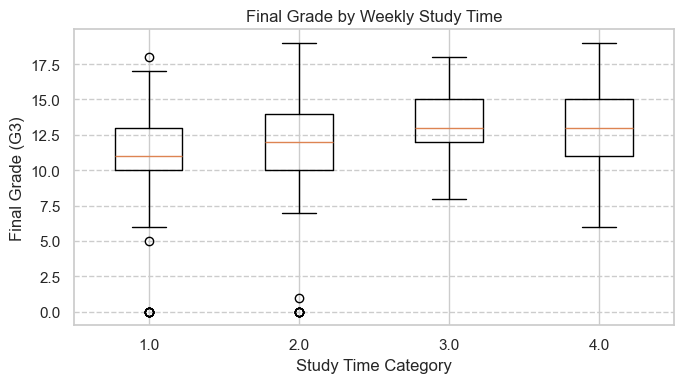

In [143]:
categories_study = sorted(df['studytime'].cat.categories)
grouped = [df.loc[df['studytime'] == cat, 'G3'].values for cat in categories_study]

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(grouped, positions=range(1, len(categories_study) + 1))

ax.set_title("Final Grade by Weekly Study Time")
ax.set_xlabel("Study Time Category")
ax.set_ylabel("Final Grade (G3)")
ax.set_xticks(range(1, len(categories_study) + 1))
ax.set_xticklabels(categories_study)
ax.grid(axis="y", linestyle="--")

plt.tight_layout()
plt.show()

The boxplot shows a slight upward trend in median G3 scores as studytime increases. However, extensive overlap in the interquartile ranges indicates considerable variability within each category. This suggests that although higher studytime may contribute positively to performance, it is not a dominant predictor and likely interacts with other academic or socioeconomic factors, providing weak support to the hypothesis.

**Parental Education Is Associated With Student Achievement**

**Hypothesis:** Students whose mothers have higher educational attainment achieve higher final grades because parental education is a dominant contribution to academic support, expectations, and learning environment quality. Boxplot is used to display how grade distributions shift across ordered parental education levels.

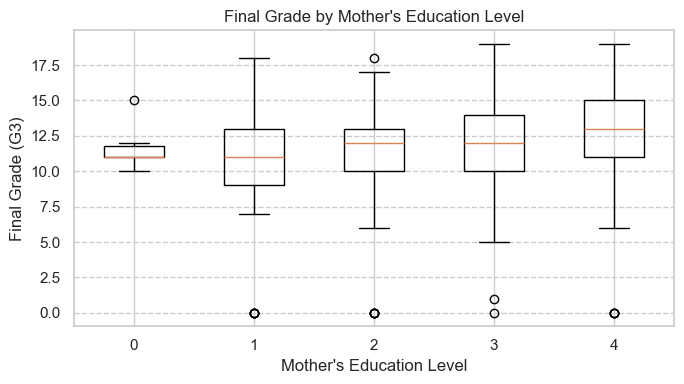

In [144]:
# box plot of G3 by Medu
categories_medu = sorted(df['Medu'].cat.categories)
grouped_medu = [df.loc[df['Medu'] == cat, 'G3'].values for cat in categories_medu]
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(grouped_medu, positions=range(1, len(categories_medu) + 1))
ax.set_title("Final Grade by Mother's Education Level")
ax.set_xlabel("Mother's Education Level")
ax.set_ylabel("Final Grade (G3)")
ax.set_xticks(range(1, len(categories_medu) + 1))
ax.set_xticklabels(categories_medu)
ax.grid(axis="y", linestyle="--")
plt.tight_layout()
plt.show()

The distribution of G3 scores shows a **gradual increase in median performance** as the mother's education level rises. However, the major overlap across levels 1 - 4 indicates that the relationship is **moderate**, and students from these education levels can achieve both high and low marks. Therefore, visualization suggests a moderate influence of maternal education on student achievement.

**Internet Access Affects Study Behavior**

**Hypothesis:** Students with home internet access study less due to increased availability of digital distractions. Countplot is used to show differences in the frequency distribution of ordered categories across nominal groups.

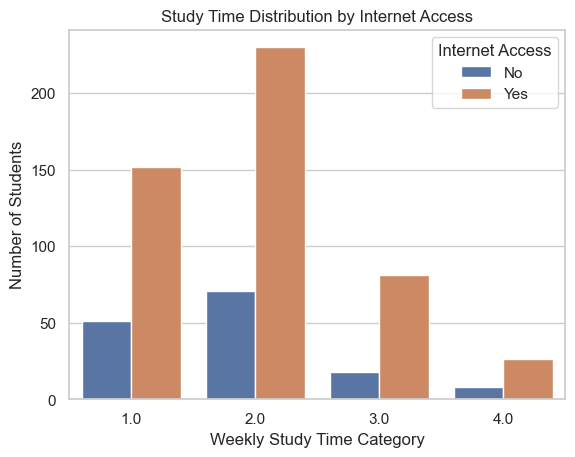

In [145]:
# Countplots in the frequency distribution of ordered categories across nominal groups.
sns.countplot(x="studytime", hue="internet", data=df)
plt.title("Study Time Distribution by Internet Access")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Number of Students")
plt.legend(title="Internet Access", labels=["No", "Yes"])
plt.show()

The plot does **not** support the hypothesis. Students with internet access are not over-represented in lower studytime categories; instead, they appear at higher frequencies across all categories, including the highest (3–4). This suggests that internet access alone does not reduce study effort and that other factors (e.g., self-regulation, parental supervision) likely moderate the relationship.

## Task 2.3: Scatter Matrix

The scatter plot of all numeric variables in the dataset is visualized to inspect the overall relationships, trends, and noise patterns across all numeric features.



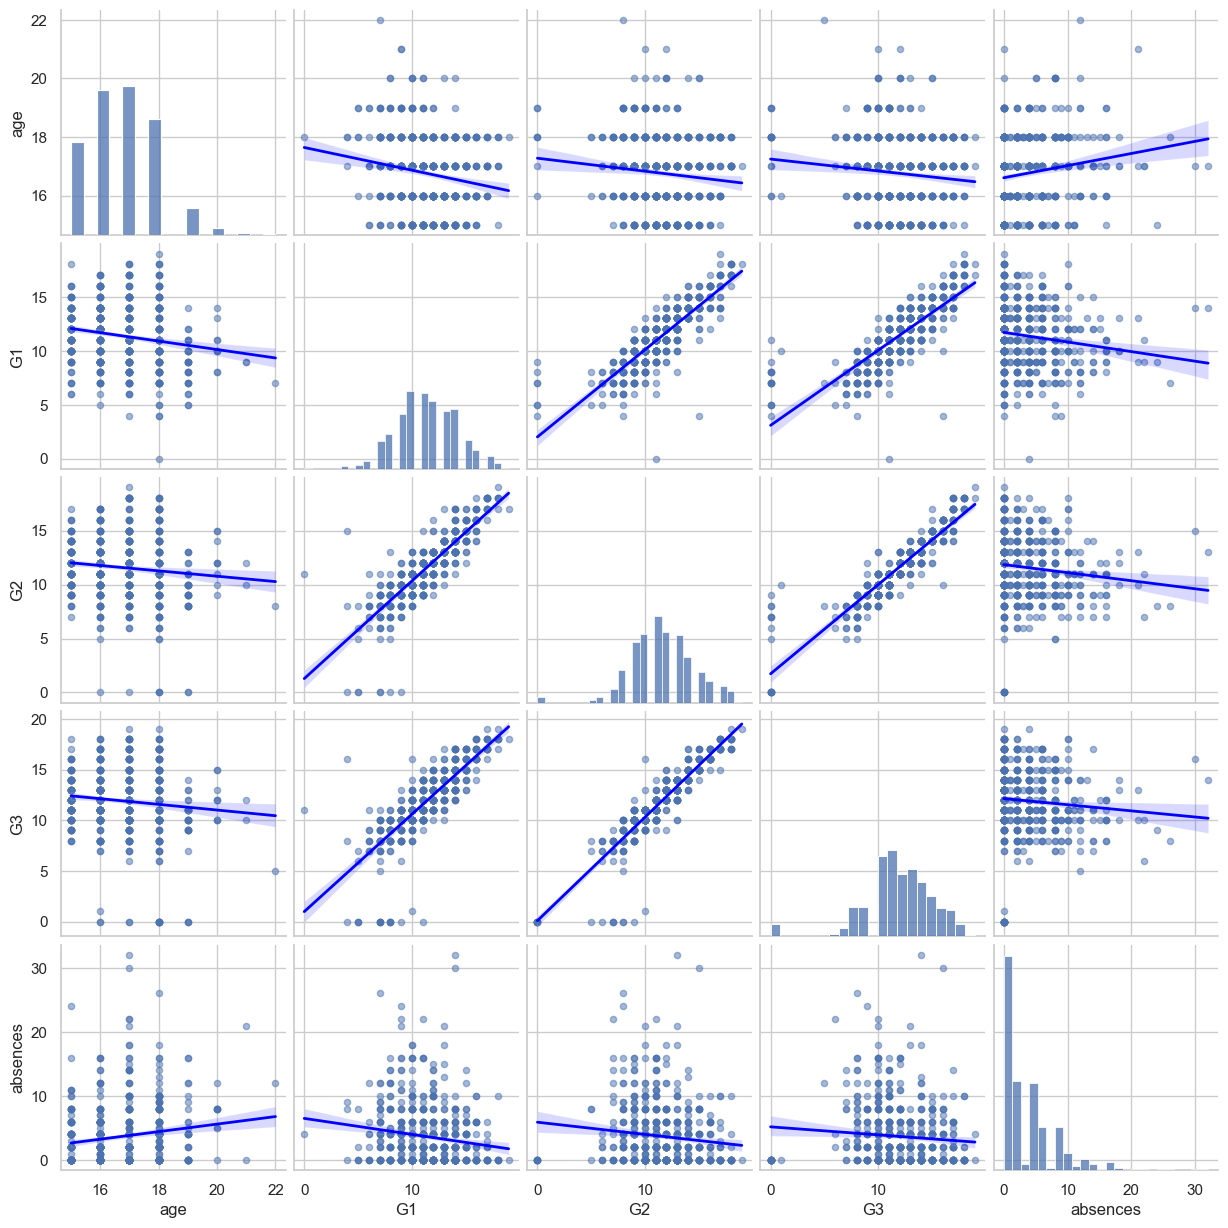

In [146]:
# Create pairplot with regression trend lines
sns.pairplot(
    df[numeric_cols],
    kind="reg",
    plot_kws={
        "scatter_kws": {"alpha": 0.5, "s": 20},
        "line_kws": {"color": "blue", "linewidth": 2},
    },
)


Based on the full scatter plot, both **age** and **absences** produce scatterplots that are visually cluttered, weakly correlated to other numeric features, making it difficult to produce a clear relationship with other columns. In contrast, all three grade pairs (*G1–G2*, *G2–G3*, and *G1–G3*) display **strong relationships to each other** and informative in predicting the academic assessment.

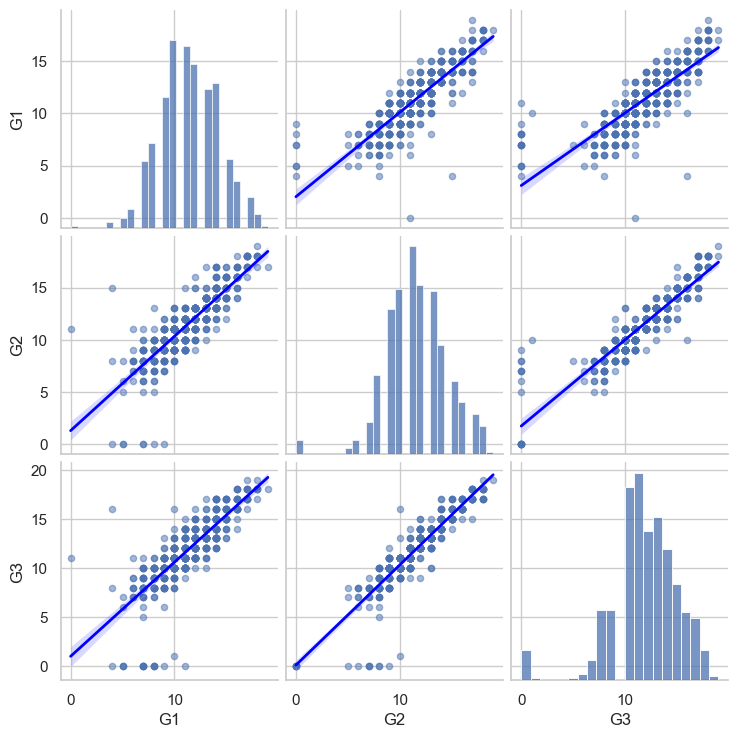

In [147]:
# Create pairplot with regression trend lines
sns.pairplot(
    df[['G1', 'G2', 'G3']],
    kind="reg",
    plot_kws={
        "scatter_kws": {"alpha": 0.5, "s": 20},
        "line_kws": {"color": "blue", "linewidth": 2},
    },
)

The scatter matrix of G1, G2, and G3 shows strong, clear positive linear relationships across all grade pairs, indicating that student performance is highly consistent throughout the academic year. G1 and G2 display the tightest clustering, demonstrating that early-term results closely predict mid-term achievement. The G2–G3 relationship is similarly strong, while the slightly wider spread in the G1–G3 plot reflects expected changes in performance over time. Overall, the visualization highlights that earlier grades are reliable predictors of final outcomes, making these three variables effective for illustrating academic progression.

# Task 3: Missing Value Imputation

## Task 3.1: Imputation Method Comparison

In [148]:
df_mean_imputed = df.copy()
df_median_imputed = df.copy()
df_mode_imputed = df.copy()
df_interpolated = df.copy()

In [149]:
# Mean imputation for numeric columns
df_mean_imputed[numeric_cols] = df_mean_imputed[numeric_cols].fillna(df_mean_imputed[numeric_cols].mean())
print("Mean imputation completed for numeric columns.")

# Median imputation for numeric columns
df_median_imputed[numeric_cols] = df_median_imputed[numeric_cols].fillna(df_median_imputed[numeric_cols].median())
print("Median imputation completed for numeric columns.")

# Interpolation for numeric columns
df_interpolated[numeric_cols] = df_interpolated[numeric_cols].interpolate(method='linear')
print("Interpolation completed for numeric columns.")

# Save imputed datasets to csv files
df_mean_imputed.to_csv("student_fix1.csv", index=False)
df_median_imputed.to_csv("student_fix2.csv", index=False)
df_interpolated.to_csv("student_fix3.csv", index=False)

Mean imputation completed for numeric columns.
Median imputation completed for numeric columns.
Interpolation completed for numeric columns.


In [150]:
def compare_imputation_metrics(
    df_original, df_imputed, column_name, imputation_method="Imputation"
):
    """
    Compare distribution metrics between original and imputed dataframes for a specific column.
    """
    # Extract the columns
    original_col = df_original[column_name]
    imputed_col = df_imputed[column_name]

    # Calculate differences
    metrics_comparison = pd.DataFrame(
        {
            "Metric": ["Mean", "Median", "Std", "Skewness"],
            "Original": [
                original_col.mean() if column_name in numeric_cols else np.nan,
                original_col.median() if column_name in numeric_cols else np.nan,
                original_col.std() if column_name in numeric_cols else np.nan,
                original_col.skew() if column_name in numeric_cols else np.nan,
            ],
            "Imputed": [
                imputed_col.mean() if column_name in numeric_cols else np.nan,
                imputed_col.median() if column_name in numeric_cols else np.nan,
                imputed_col.std() if column_name in numeric_cols else np.nan,
                imputed_col.skew() if column_name in numeric_cols else np.nan,
            ],
        }
    )

    # Calculate absolute and percentage differences
    metrics_comparison["Absolute_Diff"] = abs(
        metrics_comparison["Imputed"] - metrics_comparison["Original"]
    )
    metrics_comparison["Percent_Change"] = (
        metrics_comparison["Absolute_Diff"] / metrics_comparison["Original"].abs()
    ) * 100

    # Round for display
    metrics_comparison = metrics_comparison.round(4)

    # Create visualization
    _, ax = plt.subplots(figsize=(7, 5))

    # 1. Histogram comparison
    ax.hist(
        original_col,
        bins=30,
        alpha=0.5,
        label="Original",
        color="blue",
        edgecolor="black",
    )
    ax.hist(
        imputed_col,
        bins=30,
        alpha=0.5,
        label=imputation_method,
        color="red",
        edgecolor="black",
    )

    ax.set_title(
        f"Distribution Comparison: {column_name}", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel(column_name)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)



    # Display metrics table
    print("\n" + "=" * 80)
    print(f"METRICS COMPARISON: {column_name} ({imputation_method})")
    print("=" * 80)
    display(metrics_comparison)

    print(f"Missing values imputed: {df_original[column_name].isna().sum()}")
    print(
        f"Imputation rate: {(df_original[column_name].isna().sum() / len(df_original)) * 100:.2f}%"
    )

    return metrics_comparison


METRICS COMPARISON: G2 (Mean Imputation)


,Metric,Original,Imputed,Absolute_Diff,Percent_Change
0,Mean,11.5752,11.5752,0.0000,0.0000
1,Median,11.0000,11.0000,0.0000,0.0000
2,Std,2.9180,2.9090,0.0090,0.3091
3,Skewness,-0.3625,-0.3636,0.0011,0.3082


Missing values imputed: 4
Imputation rate: 0.62%


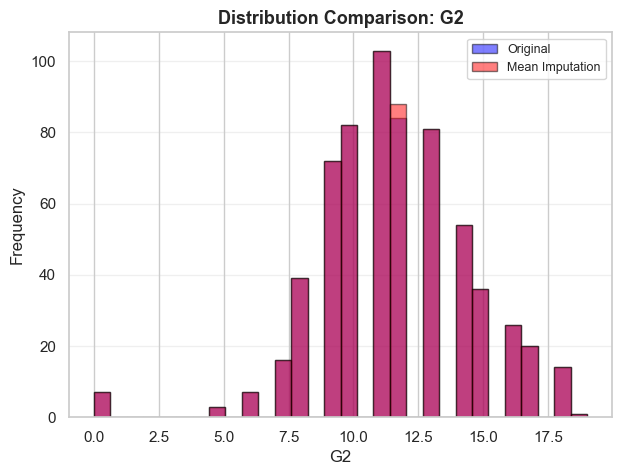

In [151]:
metrics_mean = compare_imputation_metrics(df, df_mean_imputed, "G2", "Mean Imputation")

**Mean Imputation (imputated file at "student_fix1.csv")**

Mean imputation produces similarly minimal changes, with a small increase in the bin around the mean. The standard deviation decreases by **0.30%**, and skewness changes by only **0.0011** (0.31%). Mean imputation inherently **underestimates variance** and can introduce **bias**, particularly when distributions are skewed or have outliers. In this dataset, the effect is negligible because the missing proportion is extremely small and the distribution of G2 is approximately symmetric. The distribution is preserved visually and numerically, but the bias limitation should be investigated if there are many missing values.


METRICS COMPARISON: G2 (Median Imputation)


,Metric,Original,Imputed,Absolute_Diff,Percent_Change
0,Mean,11.5752,11.5716,0.0035,0.0306
1,Median,11.0000,11.0000,0.0000,0.0000
2,Std,2.9180,2.9094,0.0087,0.2972
3,Skewness,-0.3625,-0.3598,0.0026,0.7263


Missing values imputed: 4
Imputation rate: 0.62%


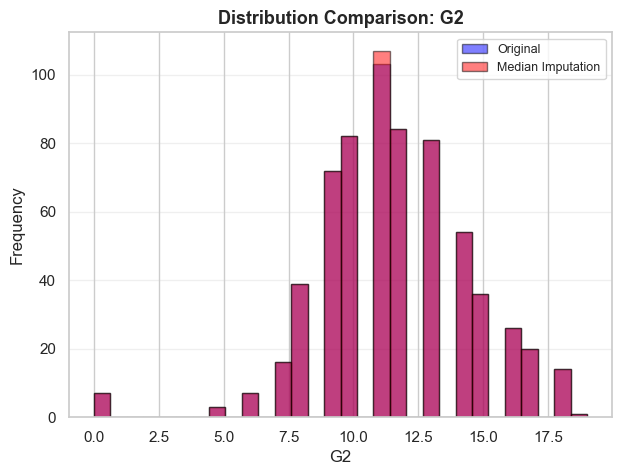

In [152]:
metrics_median = compare_imputation_metrics(df, df_median_imputed, "G2", "Median Imputation")

**Median Imputation (imputated file at "student_fix2.csv")**

Median imputation introduces minimal visual changes to the G2 histogram, with only a slightly higher bar at the median category. The mean shifts by **0.03%**, the standard deviation decreases by **0.30%**, and skewness changes by <1%, while the median remains identical. Although median imputation is robust and preserves central tendency well, it **reduces variance** because repeated identical values replace genuine variability and can introduce **heaping** if many values are missing. This is suitable for G2 since it has few missing values.


METRICS COMPARISON: G2 (Interpolation)


,Metric,Original,Imputed,Absolute_Diff,Percent_Change
0,Mean,11.5752,11.5763,0.0011,0.0093
1,Median,11.0000,11.0000,0.0000,0.0000
2,Std,2.9180,2.9098,0.0083,0.2830
3,Skewness,-0.3625,-0.3643,0.0018,0.4919


Missing values imputed: 4
Imputation rate: 0.62%


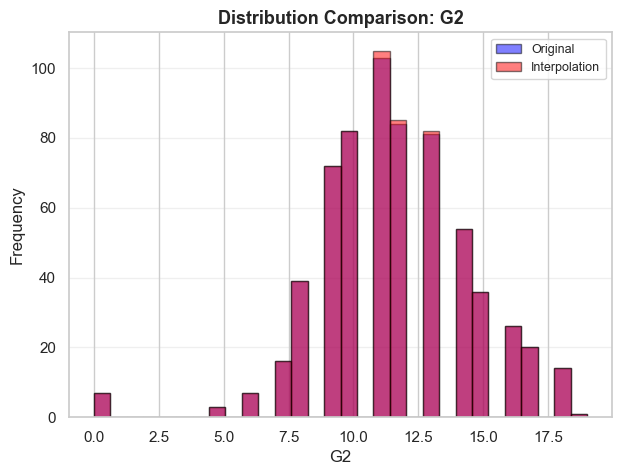

In [153]:
metrics_interpolated = compare_imputation_metrics(df, df_interpolated, "G2", "Interpolation")

**Linear Interpolation (imputated file at "student_fix3.csv")**

The histogram shows that **interpolation imputation produces slight change** to the G2 distribution with small differences in the mid-range bins. The mean changes by **0.009%**, standard deviation decreases by **0.28%**, and skewness shifts by <0.5%; the median is unchanged. G2 sits in an ordered dataset (score listed in sequence), allowing local interpolation to produce realistic values. Unlike mean or median imputation, interpolation preserves natural variations because it uses neighboring values rather than a single central estimate.

In [154]:
comparison_summary = pd.DataFrame(
    {
        "Metric": metrics_mean["Metric"],
        "Original": metrics_mean["Original"],

        "Mean_%_Change": metrics_mean["Percent_Change"],

        "Median_%_Change": metrics_median["Percent_Change"],

        "Interpolated_%_Change": metrics_interpolated["Percent_Change"],
    }
)
display(comparison_summary)

,Metric,Original,Mean_%_Change,Median_%_Change,Interpolated_%_Change
0,Mean,11.5752,0.0000,0.0306,0.0093
1,Median,11.0000,0.0000,0.0000,0.0000
2,Std,2.9180,0.3091,0.2972,0.2830
3,Skewness,-0.3625,0.3082,0.7263,0.4919


Mean and median imputations slightly compress variance because they insert repeated values at fixed points, whereas interpolation maintains continuity by modelling local structure. These observations confirm that the statistical characteristics of G2—its center, spread, and shape—remain effectively intact under all three imputation strategies, with interpolation offering the most structure-preserving outcome.

In [155]:
# ============================================================================
# CREATE DATASET WITHOUT OUTLIERS (Using IQR Method)
# ============================================================================

print("=" * 80)
print("OUTLIER REMOVAL USING IQR METHOD")
print("=" * 80)

# Create a copy of the dataframe
df_no_outliers = df.copy()

# Function to remove outliers using IQR method
def remove_outliers_iqr(data, column):
    """
    Remove outliers from a column using the IQR method.
    Outliers are defined as values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
    
    # Filter out outliers
    mask = (data[column] >= lower_bound) & (data[column] <= upper_bound)
    
    return mask, outliers, lower_bound, upper_bound

# Apply outlier removal to all numeric columns
print("\nOutlier Detection Summary:")
print("-" * 80)

outlier_summary = []
combined_mask = pd.Series([True] * len(df_no_outliers), index=df_no_outliers.index)

for col in numeric_cols:
    mask, outlier_count, lower, upper = remove_outliers_iqr(df_no_outliers, col)
    combined_mask &= mask
    
    outlier_summary.append({
        'Column': col,
        'Outliers_Found': outlier_count,
        'Lower_Bound': f"{lower:.2f}",
        'Upper_Bound': f"{upper:.2f}",
        'Original_Count': len(df_no_outliers)
    })
    
    print(f"{col:12} | Outliers: {outlier_count:3} | Range: [{lower:6.2f}, {upper:6.2f}]")

# Apply combined mask to remove rows with ANY outliers
df_no_outliers = df_no_outliers[combined_mask].copy()

print("\n" + "=" * 80)
print(f"Original dataset: {len(df)} rows")
print(f"Dataset without outliers: {len(df_no_outliers)} rows")
print(f"Rows removed: {len(df) - len(df_no_outliers)} ({(len(df) - len(df_no_outliers))/len(df)*100:.2f}%)")
print("=" * 80)

# Display outlier summary
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

OUTLIER REMOVAL USING IQR METHOD

Outlier Detection Summary:
--------------------------------------------------------------------------------
age          | Outliers:   1 | Range: [ 13.00,  21.00]
G1           | Outliers:  17 | Range: [  5.50,  17.50]
G2           | Outliers:  25 | Range: [  5.50,  17.50]
G3           | Outliers:  16 | Range: [  4.00,  20.00]
absences     | Outliers:  21 | Range: [ -9.00,  15.00]

Original dataset: 649 rows
Dataset without outliers: 574 rows
Rows removed: 75 (11.56%)


,Column,Outliers_Found,Lower_Bound,Upper_Bound,Original_Count
0,age,1,13.00,21.00,649
1,G1,17,5.50,17.50,649
2,G2,25,5.50,17.50,649
3,G3,16,4.00,20.00,649
4,absences,21,-9.00,15.00,649



STANDARD DEVIATION COMPARISON

📊 Standard Deviation Impact Analysis:


,Column,Std_With_Outliers,Std_Without_Outliers,Std_Difference,Pct_Change
0,age,1.237,1.218,0.019,1.553
1,G1,2.765,2.465,0.301,10.879
2,G2,2.918,2.430,0.488,16.731
3,G3,3.233,2.499,0.734,22.702
4,absences,4.648,3.564,1.084,23.329


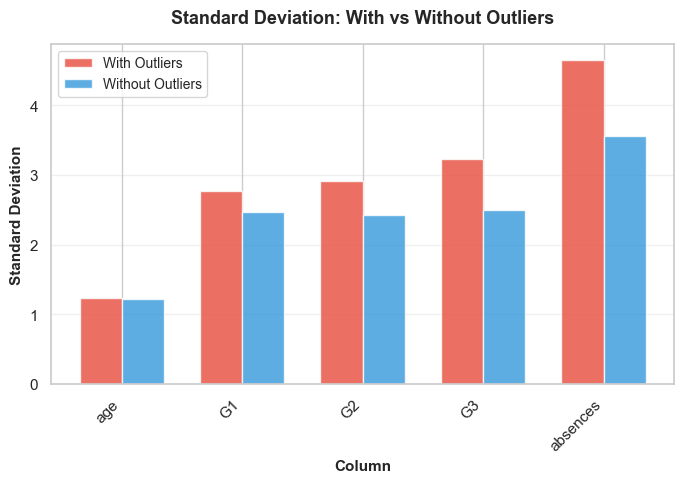

In [156]:
# ============================================================================
# COMPARE STANDARD DEVIATIONS: WITH vs WITHOUT OUTLIERS
# ============================================================================

print("\n" + "=" * 80)
print("STANDARD DEVIATION COMPARISON")
print("=" * 80)

# Calculate standard deviations for both datasets
std_comparison = pd.DataFrame({
    'Column': numeric_cols,
    'Std_With_Outliers': [df[col].std() for col in numeric_cols],
    'Std_Without_Outliers': [df_no_outliers[col].std() for col in numeric_cols],
})

# Calculate the difference and percentage change
std_comparison['Std_Difference'] = (
    std_comparison['Std_With_Outliers'] - std_comparison['Std_Without_Outliers']
)
std_comparison['Pct_Change'] = (
    (std_comparison['Std_Difference'] / std_comparison['Std_With_Outliers']) * 100
)

# Round for better display
std_comparison = std_comparison.round(3)

print("\n📊 Standard Deviation Impact Analysis:")
display(std_comparison)

# Visual comparison
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# Bar chart comparison
x = range(len(numeric_cols))
width = 0.35

ax.bar([i - width/2 for i in x], std_comparison['Std_With_Outliers'], 
       width, label='With Outliers', alpha=0.8, color='#e74c3c')
ax.bar([i + width/2 for i in x], std_comparison['Std_Without_Outliers'], 
       width, label='Without Outliers', alpha=0.8, color='#3498db')

ax.set_xlabel('Column', fontsize=11, fontweight='bold')
ax.set_ylabel('Standard Deviation', fontsize=11, fontweight='bold')
ax.set_title('Standard Deviation: With vs Without Outliers', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Task 3.2: Outlier Analysis

### Impact of Outliers on Standard Deviation

Standard deviation is **strongly affected by outliers** because it measures how far each value lies from the mean. Outliers are placed far from the center of the distribution, so they contribute disproportionately large squared deviations to the equation result, inflating the standard deviation even if only a single extreme value exists. As a result, the standard deviation may no longer reflect the variability of the typical data, and comparisons between variables or groups become misleading. This sensitivity is why robust alternatives (e.g., IQR, median absolute deviation) are often preferred when outliers are present, as they rely on medians and percentile-based ranges, which are not influenced by extreme values.

The same is applied in this dataset, outliers significantly inflate standard deviation. The grade variables increase by **23%** when outliers are included, and **absences** rises even more (**23.3%**). Even **age**, which has fewer extreme values, shows a small but noticeable increase (**1.55%**). This confirms that standard deviation in this dataset is strongly affected by outliers.

### Outlier Retention Criteria

An outlier should not be removed when it represents a real, meaningful observation rather than an error. Outliers must remain when they reflect genuine extreme behavior (e.g., very high absences, unusually low grades), capture important subgroups, or signal rare but valid patterns in the dataset. Removing such values can erase critical insights, distort the distribution, reduce model validity, or eliminate groups that are academically or behaviorally at risk. Outliers should only be removed when they are proven to be data-entry errors, impossible values, or inconsistent with the variable’s documented range.

### Outlier Detection Methodology

In this dataset, all five numeric variables: age, absences, G1, G2, and G3, contain outliers, which fall into two categories: **domain-invalid outliers** and **statistical outliers**. Domain validation, based on UCI attribute definitions, identified impossible values such as ages **170** (outside 15 - 22), and grade values such as **132** (outside the 0–20 scale). These are errors and were removed or replaced with NaN.

Statistical outliers were detected using the IQR rule . For the grade variables, scores at the lower and upper ends (0 - 5 and 18 - 20) appear as outliers but are legitimate extremes of academic performance. Absences above 20 also qualify as statistical outliers but plausibly reflect real behavioural patterns. Age 22, although rare, remains within the documented domain and should be retained.

### Summary

In summary, every numeric column contains outliers, but only the **domain-invalid** values should be removed. The statistical outliers represent genuine variation and therefore remain important to preserve. Using both domain constraints and statistical detection techniques provides a balanced and defensible approach to maintaining data quality.

# Task 4: MovieLens Dataset Analysis

## Dataset Loading

The **u.item** and **u.data** files were loaded into separate dataframes, with column names applied according to the official MovieLens specification to ensure the correct interpretation of both the movie-level metadata and the user–movie rating interactions. Both dataframes use **item_id** as a common key. Because **u.data** contains multiple ratings per film while **u.item** provides a single metadata record for each title, several integrity checks were conducted prior to merging to prevent structural inconsistencies.

In [157]:
# retrieve ml-100k dataset u.data and u.item files
u_data = pd.read_csv(
    f"{MOVIE_LENS_PATH}/u.data",
    sep="\t",
    header=None,
    names=["user_id", "item_id", "rating", "timestamp"],
)
genre_columns = [
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western",
]
item_data = pd.read_csv(
    f"{MOVIE_LENS_PATH}/u.item",
    sep="|",
    header=None,
    encoding="latin-1",
    names=["item_id", "title", "release_date", "video_release_date", "IMDb_URL"]
    + [i for i in genre_columns],
)
print("User Ratings Data", u_data.shape)
display(u_data.head())
print("Movie Item Data", item_data.shape)
display(item_data.head())

User Ratings Data (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Movie Item Data (1682, 24)


,item_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0


**Completeness of key fields:** A preliminary check confirmed that neither dataset contained missing values in the **item_id** column. This ensured that all records could be reliably matched during the merge.

In [158]:
# Check for null item_ids in u.data and u.item
print("Null item_ids in u_data: ", u_data["item_id"].isnull().sum())
print("Null item_ids in item_data: ", item_data["item_id"].isnull().sum())

Null item_ids in u_data:  0
Null item_ids in item_data:  0


**Uniqueness of records:** A second verification established that neither **u.item** nor **u.data** included duplicate rows. This is essential because duplicate metadata would misrepresent distinct films, and duplicate rating entries would incorrectly inflate user interaction counts.

In [159]:
# Display rows with duplicate in u_data and item_data
print("Duplicate rows in u_data: ", u_data.duplicated().sum())
print("Duplicate rows in item_data: ", item_data.duplicated().sum())

Duplicate rows in u_data:  0
Duplicate rows in item_data:  0


**Referential integrity across datasets:** A third check verified that every **item_id** present in the ratings dataset appeared in the metadata file, confirming that no “orphan” ratings existed that would otherwise produce incomplete merge results.

In [160]:
missing_in_items = set(u_data["item_id"]) - set(item_data["item_id"])
print(f"Item IDs in u.data missing from u.item: {len(missing_in_items)}")

Item IDs in u.data missing from u.item: 0


In [161]:
df_mlens = pd.merge(u_data, item_data, on="item_id", how="left")
df_mlens.head()

,user_id,item_id,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0


In [162]:
# ============================================================================
# MOVIELENS DATA PREPARATION - INITIAL INSPECTION
# ============================================================================

print("=" * 80)
print("MOVIELENS 100K DATASET - INITIAL INSPECTION")
print("=" * 80)

print(f"\n📊 Dataset Shape: {df_mlens.shape[0]:,} rows × {df_mlens.shape[1]} columns")

print("\n" + "=" * 80)
print("DATA TYPES SUMMARY")
print(df_mlens.info())

MOVIELENS 100K DATASET - INITIAL INSPECTION

📊 Dataset Shape: 100,000 rows × 27 columns

DATA TYPES SUMMARY
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             100000 non-null  int64  
 1   item_id             100000 non-null  int64  
 2   rating              100000 non-null  int64  
 3   timestamp           100000 non-null  int64  
 4   title               100000 non-null  object 
 5   release_date        99991 non-null   object 
 6   video_release_date  0 non-null       float64
 7   IMDb_URL            99987 non-null   object 
 8   unknown             100000 non-null  int64  
 9   Action              100000 non-null  int64  
 10  Adventure           100000 non-null  int64  
 11  Animation           100000 non-null  int64  
 12  Children            100000 non-null  int64  
 13  Comedy              100000 

- **Dataset Dimension**: The merged dataset contains **100,000 rows** and **27 columns**. All expected variables from both **data** and **u.item** are present, confirming a complete and accurate merge with no dropped or duplicated records.

- **Data type**: The current data types align with the UCI MovieLens specification: **release_date** is stored as a datetime object (e.g., *1-Jan-1999*), and **timestamp** as a single numeric value (e.g., *885853415*). While these representations are correct, they may introduce unnecessary complexity during modelling. Datetime strings and mixed temporal formats often behave like **categorical labels**, which can interfere with algorithms that expect strictly numerical inputs. Converting these fields into a consistent, numeric representation (such as *1-1-1999)* simplifies preprocessing and ensures that the temporal information can be interpreted meaningfully by machine learning models.

- **Missing values**: A targeted missing-value assessment identified such as9 missing **release_date** entries, ****100% missing **video_release_date**, and 13 missing entries of  ****All other columns are fully complete with no missing values.

In [163]:
df_mlens.describe(include='all')

,user_id,item_id,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,100000.00000,100000.000000,100000.000000,1.000000e+05,100000,99991,0.0,99987,100000.0000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000
unique,NaN,NaN,NaN,NaN,1664,240,NaN,1660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Star Wars (1977),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Star%20Wars%2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,583,9932,NaN,583,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,462.48475,425.530130,3.529860,8.835289e+08,NaN,NaN,NaN,NaN,0.0001,0.255890,0.137530,0.036050,0.071820,0.298320,0.080550,0.007580,0.398950,0.013520,0.017330,0.053170,0.049540,0.052450,0.194610,0.12730,0.21872,0.093980,0.018540
std,266.61442,330.798356,1.125674,5.343856e+06,NaN,NaN,NaN,NaN,0.0100,0.436362,0.344408,0.186416,0.258191,0.457523,0.272144,0.086733,0.489685,0.115487,0.130498,0.224373,0.216994,0.222934,0.395902,0.33331,0.41338,0.291802,0.134894
min,1.00000,1.000000,1.000000,8.747247e+08,NaN,NaN,NaN,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,254.00000,175.000000,3.000000,8.794487e+08,NaN,NaN,NaN,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
50%,447.00000,322.000000,4.000000,8.828269e+08,NaN,NaN,NaN,NaN,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
75%,682.00000,631.000000,4.000000,8.882600e+08,NaN,NaN,NaN,NaN,0.0000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000


- **Data Validity**: All examined variables conform to the expected ranges and constraints defined by the MovieLens dataset. **Ratings** fall strictly within the 1–5 scale and **genre indicator columns** contain only binary values (0 or 1).

## Data Quality Audit

**Release Date Format Validation:** The **release_date** field was evaluated for incorrect or inconsistent date formats, including invalid calendar dates and deviations from the expected DD-MMM-YYYY structure used in the MovieLens 100K dataset. All entries followed a valid and interpretable date format. No malformed or ambiguous dates were detected.

In [164]:
unique_dates = df_mlens["release_date"].dropna().unique()
print(f"\nTotal unique dates to check: {len(unique_dates)}")

# Try to parse all dates
invalid_dates = []
valid_count = 0

for date_str in unique_dates:
    try:
        pd.to_datetime(date_str, format="%d-%b-%Y")
        valid_count += 1
    except:
        invalid_dates.append(date_str)

# Display results
print(f"\n📊 Validation Results:")
print(f"   ✓ Valid dates: {valid_count}")
print(f"   ✗ Invalid dates: {len(invalid_dates)}")


Total unique dates to check: 240

📊 Validation Results:
   ✓ Valid dates: 240
   ✗ Invalid dates: 0


**Whitespace Detection in Text Fields:** Textual fields such as **title** and **IMDb_URL** were scanned for leading or trailing whitespace, which can introduce duplicate-like entries or hinder string matching. There are **15 movie titles** contained unnecessary leading or trailing whitespace and all other text fields were clean, exhibiting no extraneous whitespace. These whitespace issues represent formatting noise rather than semantic errors but should be corrected to ensure clean joins, consistent sorting, and accurate text analysis.

In [165]:
# identify object row with extra whitespace
for col in df_mlens.select_dtypes(include=["object"]).columns:
    whitespace_mask = df_mlens[col].notna() & (
        df_mlens[col].astype(str) != df_mlens[col].astype(str).str.strip()
    )
    whitespace_count = whitespace_mask.sum()

    if whitespace_count > 0:
        print(f"'{col}' has {whitespace_count} entries with whitespace")
    else:
        print(f"'{col}' - no whitespace detected")

'title' has 15 entries with whitespace
'release_date' - no whitespace detected
'IMDb_URL' - no whitespace detected


**Year Mismatch Between Title and Release Date**

For titles that embed a year (e.g., *Batman (1989)*), the numeric year in the title was compared with the year derived from the **release_date** field. While **55 mismatches** were, these discrepancies are not considered data errors. A title year may refer to the production year rather than release year, a re-release or remaster edition, or a stylistic title convention unrelated to official release chronology. Thus, these mismatches require no corrective action.

In [166]:
# Convert release_date to datetime first
df_mlens_temp = df_mlens.copy()
df_mlens_temp['release_date'] = pd.to_datetime(df_mlens_temp['release_date'], format="%d-%b-%Y", errors='coerce')

# Extract year from title and compare with release year
df_mismatch_title_year = df_mlens_temp[
    (df_mlens_temp['release_date'].notna()) &
    (df_mlens_temp['release_date'].dt.year - df_mlens_temp['title'].str.extract(r'\((\d{4})\)').astype(float)[0] > 1)
]

# get unique title years
df_mismatch_title_year = df_mismatch_title_year.drop_duplicates(subset=['item_id'])
print(f"Total movies with title year and release year mismatch: {len(df_mismatch_title_year)}")
df_mismatch_title_year.head()

Total movies with title year and release year mismatch: 55


,user_id,item_id,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
53,25,181,5,885853415,Return of the Jedi (1983),1997-03-14,NaN,http://us.imdb.com/M/title-exact?Return%20of%2...,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0
59,292,515,4,881103977,"Boot, Das (1981)",1997-04-04,NaN,"http://us.imdb.com/M/title-exact?Boot,%20Das%2...",0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
99,135,23,4,879857765,Taxi Driver (1976),1996-02-16,NaN,http://us.imdb.com/M/title-exact?Taxi%20Driver...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
680,22,128,5,878887983,Supercop (1992),1996-07-26,NaN,http://us.imdb.com/M/title-exact?Police%20Stor...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1271,181,1334,1,878962240,Somebody to Love (1994),1996-06-14,NaN,http://us.imdb.com/Title?Somebody+to+Love+(1996),0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


**Data Range Validity Checks**

Key fields were validated against the constraints defined by the MovieLens 100K documentation.

- **Ratings:** All values fall within the valid 1–5 integer rating scale.
- **Genre Indicators:** All genre columns contain only binary values (0 or 1), consistent with the dataset’s multi-genre encoding.
- **Timestamps:** All timestamps fall within the valid Unix epoch range with the earliest timestamp: **1997-09-20 03:05:10** and latest timestamp is **1998-04-22 23:10:38**

These values align with the temporal scope of the MovieLens 100K dataset, which collected ratings between late 1997 and early 1998.

In [167]:
object_cols_mlens = df_mlens.columns[8:]

print("\nCategorical columns and their unique values:")
unique_cols = pd.DataFrame(
    {
        "Feature": list(object_cols_mlens),
        "Unique Values": [df_mlens[col].unique() for col in object_cols_mlens],
    }
)
# display all columns without truncation


with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    display(unique_cols)


Categorical columns and their unique values:


,Feature,Unique Values
0,unknown,"[0, 1]"
1,Action,"[0, 1]"
2,Adventure,"[0, 1]"
3,Animation,"[0, 1]"
4,Children,"[0, 1]"
5,Comedy,"[1, 0]"
6,Crime,"[0, 1]"
7,Documentary,"[0, 1]"
8,Drama,"[0, 1]"
9,Fantasy,"[0, 1]"


In [168]:
# ============================================================================
# DATA QUALITY AUDIT - VALUE RANGES & ANOMALIES
# ============================================================================

print("\n" + "=" * 80)
print("VALUE RANGE VALIDATION")
print("=" * 80)

# Check rating range (should be 1-5 for MovieLens)
rating_unq = df_mlens['rating'].unique().tolist()
print(f"\n📊 Rating Statistics:")
print(f"   Unique ratings: {sorted(rating_unq)}")

# Check timestamp validity
print(f"\n⏰ Timestamp Range:")
print(f"   Earliest: {pd.to_datetime(df_mlens['timestamp'], unit='s').min()}")
print(f"   Latest: {pd.to_datetime(df_mlens['timestamp'], unit='s').max()}")

is_valid_genres = True
for col in genre_columns:
    unique_vals = df_mlens[col].unique()
    if not set(unique_vals).issubset({0, 1}):
        print("   ⚠️  Invalid values found in genre columns:")
        print(f"      {col}: {unique_vals}")
        is_valid_genres = False
        break

if is_valid_genres: print("\nAll genre columns contain only binary values (0/1)")


VALUE RANGE VALIDATION

📊 Rating Statistics:
   Unique ratings: [1, 2, 3, 4, 5]

⏰ Timestamp Range:
   Earliest: 1997-09-20 03:05:10
   Latest: 1998-04-22 23:10:38

All genre columns contain only binary values (0/1)


**Missing Values Review**

A completeness assessment identified missing entries across several fields:

- **video_release_date: 100% missing values** indicate that this field was never populated in MovieLens 100K.
- **release_date: 9 missing values** and the rows with NaN release_date also have unknown movie titles. These cases may require targeted lookup or imputation, depending on analytical needs.
- **IMDb_URL:** There are **13 missing values** Missing URLs may affect external data linkage but do not compromise rating analyses.

In [169]:
# ============================================================================
# DATA QUALITY AUDIT - MISSING VALUES
# ============================================================================

print("\n" + "=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)

missing_summary = pd.DataFrame({
    'Column': df_mlens.columns,
    'Missing_Count': df_mlens.isna().sum().values,
    'Missing_Percentage': (df_mlens.isna().sum().values / len(df_mlens) * 100).round(2),
    'Data_Type': df_mlens.dtypes.values
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Percentage', ascending=False
)

missing_summary


MISSING VALUES ANALYSIS


,Column,Missing_Count,Missing_Percentage,Data_Type
6,video_release_date,100000,100.00,float64
5,release_date,9,0.01,object
7,IMDb_URL,13,0.01,object


In [170]:
df_mlens[df_mlens['release_date'].isna()]  

,user_id,item_id,rating,timestamp,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
2172,130,267,5,875801239,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3781,5,267,4,875635064,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7245,268,267,3,875742077,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12475,297,267,3,875409139,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14756,319,267,4,875707690,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
15292,1,267,4,875692955,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
49295,532,267,3,875441348,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
93523,833,267,1,875655669,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
99723,422,267,4,875655986,unknown,NaN,NaN,NaN,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Data Cleaning

**Strip Extra Whitespace from Titles**: Leading and trailing whitespace in the title field was removed using .str.strip(). These inconsistencies do not change the meaning of the title but can disrupt merging, filtering, de-duplication, and text-matching tasks. Cleaning them ensures consistent string formatting and improves the reliability of all text-based analysis and operations.

In [171]:
df_mlens['title'] = df_mlens['title'].str.strip()
print("\n✓ Stripped whitespace from 'title' column")


✓ Stripped whitespace from 'title' column


**Standardize release_date to a Uniform Date Format**: The release_date column was converted to a consistent and fully parsable date format. Standardization prevents parsing errors, ensures compatibility across libraries, and supports accurate extraction of temporal components such as year, month, and day. This enhances the integrity of any time-based analysis or feature engineering.

In [172]:
df_mlens['release_date'] = pd.to_datetime(
    df_mlens['release_date'], format="%d-%b-%Y", errors='coerce'
)

**Convert timestamp to Human-Readable Datetime**: The Unix timestamps attached to user ratings were transformed into conventional datetime format. This conversion makes temporal patterns in rating behaviour more interpretable, supports the creation of time-derived features (e.g., rating lag, weekday effects), and preserves all original temporal precision.

In [173]:
df_mlens['timestamp'] = pd.to_datetime(df_mlens['timestamp'], unit='s')
print("✓ Converted 'timestamp' to datetime")

✓ Converted 'timestamp' to datetime


**Remove video_release_date (100% Missing)**: The video_release_date column was dropped because it contains no usable data and is known to be intentionally unpopulated in MovieLens 100K. Removing a fully empty feature reduces noise, prevents unnecessary handling during analysis, and maintains a clean, compact dataset.

In [174]:
# ============================================================================
# DATA CLEANING - HANDLE USELESS COLUMNS
# ============================================================================

print("\n" + "=" * 80)
print("DATA CLEANING: REMOVING USELESS COLUMNS")
print("=" * 80)


print(f"\n🗑️  Dropping columns with 100% missing data: {'video_release_date'}")

df_mlens = df_mlens.drop(columns='video_release_date')

print(f"\n✓ Columns dropped. New shape: {df_mlens.shape}")


DATA CLEANING: REMOVING USELESS COLUMNS

🗑️  Dropping columns with 100% missing data: video_release_date

✓ Columns dropped. New shape: (100000, 26)


**Retain Rows with Missing release_date**: Rows lacking a release date were kept because they represent fewer than 0.02% of entries and contain valid rating information. Removing them would lead to avoidable loss of information. Since release_date is not required for core modelling tasks, retaining these rows preserves dataset completeness.

**Retain Missing IMDb URLs**: Missing values in IMDb_URL were left unchanged because the field represents optional external metadata and does not influence user–item interactions or predictive modelling. Keeping these missing entries avoids unnecessary imputation and maintains the dataset’s structural integrity.

In [175]:
# ============================================================================
# DATA CLEANING - HANDLE MISSING VALUES
# ============================================================================

print("\n" + "=" * 80)
print("DATA CLEANING: HANDLING MISSING VALUES")
print("=" * 80)

# Investigate missing release_date and IMDb_URL
print("\n📅 Missing release_date:")
missing_release = df_mlens[df_mlens['release_date'].isna()]
print(f"   Count: {len(missing_release)}")
if len(missing_release) > 0:
    print("\n   Movies with missing release dates:")
    display(missing_release[['item_id', 'title', 'release_date']].drop_duplicates())

print("\n🔗 Missing IMDb_URL:")
missing_url = df_mlens[df_mlens['IMDb_URL'].isna()]
print(f"   Count: {len(missing_url)}")
if len(missing_url) > 0:
    print("\n   Movies with missing IMDb URLs:")
    display(missing_url[['item_id', 'title', 'IMDb_URL']].drop_duplicates())


# No rows dropped, just document the missing values
print(f"\n✓ Current shape maintained: {df_mlens.shape}")


DATA CLEANING: HANDLING MISSING VALUES

📅 Missing release_date:
   Count: 9

   Movies with missing release dates:


,item_id,title,release_date
2172,267,unknown,NaT



🔗 Missing IMDb_URL:
   Count: 13

   Movies with missing IMDb URLs:


,item_id,title,IMDb_URL
2172,267,unknown,NaN
26077,1359,Boys in Venice (1996),NaN
37163,1358,The Deadly Cure (1996),NaN



✓ Current shape maintained: (100000, 26)
